---
# Anime Data Analysis — Exploratory Data Analysis (2023)

**Author:** Aditi Verma 

**Dataset:** anime-dataset-2023.csv  
**Tools:** pandas, numpy, matplotlib, seaborn  
**Type:** Exploratory Data Analysis (EDA)

---
## 1. Project Introduction

This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the Anime Dataset 2023, sourced from MyAnimeList. The dataset contains metadata for **24,905 anime titles** covering scores, genres, studios, sources, popularity, and release information.

### Objectives
- Understand the structure and quality of the dataset
- Clean and prepare the data for analysis
- Explore distributions of scores, popularity, and engagement metrics
- Identify top genres, studios, and source materials
- Analyse release trends over time
- Examine correlations between key numerical features
- Summarise key findings


---
## 2. Dataset Overview

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

ACCENT = '#3b82d4'
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ── Load dataset ─────────────────────────────────────────────────────────────
df_raw = pd.read_csv('anime-dataset-2023.csv')
print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(3)

Shape: 24,905 rows × 24 columns


,anime_id,Name,English name,Other name,Score,Genres,Synopsis,Type,Episodes,Aired,...,Studios,Source,Duration,Rating,Rank,Popularity,Favorites,Scored By,Members,Image URL
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,8.75,"Action, Award Winning, Sci-Fi","Crime is timeless. By the year 2071, humanity ...",TV,26.0,"Apr 3, 1998 to Apr 24, 1999",...,Sunrise,Original,24 min per ep,R - 17+ (violence & profanity),41.0,43,78525,914193.0,1771505,https://cdn.myanimelist.net/images/anime/4/196...
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,8.38,"Action, Sci-Fi","Another day, another bounty—such is the life o...",Movie,1.0,"Sep 1, 2001",...,Bones,Original,1 hr 55 min,R - 17+ (violence & profanity),189.0,602,1448,206248.0,360978,https://cdn.myanimelist.net/images/anime/1439/...
2,6,Trigun,Trigun,トライガン,8.22,"Action, Adventure, Sci-Fi","Vash the Stampede is the man with a $$60,000,0...",TV,26.0,"Apr 1, 1998 to Sep 30, 1998",...,Madhouse,Manga,24 min per ep,PG-13 - Teens 13 or older,328.0,246,15035,356739.0,727252,https://cdn.myanimelist.net/images/anime/7/203...


In [3]:
# ── Column names and dtypes ───────────────────────────────────────────────────
print('Column names and dtypes:')
print(df_raw.dtypes.to_string())

Column names and dtypes:
anime_id        int64
Name              str
English name      str
Other name        str
Score             str
Genres            str
Synopsis          str
Type              str
Episodes          str
Aired             str
Premiered         str
Status            str
Producers         str
Licensors         str
Studios           str
Source            str
Duration          str
Rating            str
Rank              str
Popularity      int64
Favorites       int64
Scored By         str
Members         int64
Image URL         str


In [4]:
# ── Null / missing values ─────────────────────────────────────────────────────
print('True NaN count per column:')
print(df_raw.isnull().sum().to_string())

True NaN count per column:
anime_id        0
Name            0
English name    0
Other name      0
Score           0
Genres          0
Synopsis        0
Type            0
Episodes        0
Aired           0
Premiered       0
Status          0
Producers       0
Licensors       0
Studios         0
Source          0
Duration        0
Rating          0
Rank            0
Popularity      0
Favorites       0
Scored By       0
Members         0
Image URL       0


In [5]:
# ── Sentinel UNKNOWN counts ───────────────────────────────────────────────────
# Missing data is encoded as the string 'UNKNOWN' or 'Unknown'
sentinel_cols = ['Score', 'Rank', 'Scored By', 'Episodes', 'Premiered',
                 'Studios', 'Source', 'Type', 'Genres', 'Duration']
print('Rows with UNKNOWN/Unknown sentinel per column:')
for col in sentinel_cols:
    if col in df_raw.columns:
        n = df_raw[col].astype(str).str.upper().eq('UNKNOWN').sum()
        pct = n / len(df_raw) * 100
        print(f'  {col:<15}: {n:>5,}  ({pct:.1f}%)')

Rows with UNKNOWN/Unknown sentinel per column:
  Score          : 9,213  (37.0%)
  Rank           : 4,612  (18.5%)
  Scored By      : 9,213  (37.0%)
  Episodes       :   611  (2.5%)
  Premiered      : 19,399  (77.9%)
  Studios        : 10,526  (42.3%)
  Source         : 3,689  (14.8%)
  Type           :    74  (0.3%)
  Genres         : 4,929  (19.8%)
  Duration       :   663  (2.7%)


In [6]:
# ── Duplicate rows ────────────────────────────────────────────────────────────
print(f'Duplicate rows: {df_raw.duplicated().sum()}')

Duplicate rows: 0


In [7]:
# ── Basic statistics for natively numeric columns ─────────────────────────────
df_raw[['Popularity', 'Favorites', 'Members']].describe().round(2)

,Popularity,Favorites,Members
count,24905.00,24905.00,24905.00
mean,12265.39,432.60,37104.96
std,7187.43,4353.18,156825.24
min,0.00,0.00,0.00
25%,6040.00,0.00,209.00
50%,12265.00,1.00,1056.00
75%,18491.00,18.00,9326.00
max,24723.00,217606.00,3744541.00


---
## 3. Data Cleaning

In [8]:
# ── Working copy — never modify df_raw ───────────────────────────────────────
df = df_raw.copy()

# ── 3.1  Replace UNKNOWN sentinel with NaN ────────────────────────────────────
UNKNOWN_VARIANTS = ['UNKNOWN', 'Unknown', 'unknown']
df.replace(UNKNOWN_VARIANTS, np.nan, inplace=True)

# ── 3.2  Convert string-numeric columns to float ──────────────────────────────
for col in ['Score', 'Rank', 'Scored By', 'Episodes']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ── 3.3  Duration → minutes (numeric) ────────────────────────────────────────
def parse_duration(s):
    """Convert duration string like '24 min per ep' to total minutes (int)."""
    if pd.isna(s):
        return np.nan
    s = str(s).lower()
    total = 0
    if 'hr' in s:
        try:
            total += int(s.split('hr')[0].strip().split()[-1]) * 60
        except:
            pass
    if 'min' in s:
        try:
            total += int(s.split('min')[0].strip().split()[-1])
        except:
            pass
    return total if total > 0 else np.nan

df['Duration_min'] = df['Duration'].apply(parse_duration)

# ── 3.4  Premiered → year and season ─────────────────────────────────────────
def extract_year(s):
    if pd.isna(s):
        return np.nan
    parts = str(s).split()
    for p in parts:
        if p.isdigit() and 1900 < int(p) < 2030:
            return int(p)
    return np.nan

def extract_season(s):
    if pd.isna(s):
        return np.nan
    s = str(s).lower()
    for season in ['spring', 'summer', 'fall', 'winter']:
        if season in s:
            return season.capitalize()
    return np.nan

df['Premiere_Year'] = df['Premiered'].apply(extract_year)
df['Premiere_Season'] = df['Premiered'].apply(extract_season)

# ── 3.5  Aired → start year (fallback for missing Premiered) ─────────────────
import re

def aired_start_year(s):
    if pd.isna(s):
        return np.nan
    match = re.search(r'(\d{4})', str(s))
    if match:
        y = int(match.group(1))
        if 1900 < y < 2030:
            return y
    return np.nan

df['Aired_Start_Year'] = df['Aired'].apply(aired_start_year)

# Use Premiered year where available, fall back to Aired year
df['Release_Year'] = df['Premiere_Year'].combine_first(df['Aired_Start_Year'])

# ── Summary ───────────────────────────────────────────────────────────────────
print('Cleaning complete.')
print(f"  Score     — non-null: {df['Score'].notna().sum():,}")
print(f"  Rank      — non-null: {df['Rank'].notna().sum():,}")
print(f"  Scored By — non-null: {df['Scored By'].notna().sum():,}")
print(f"  Episodes  — non-null: {df['Episodes'].notna().sum():,}")
print(f"  Release_Year — non-null: {df['Release_Year'].notna().sum():,}")
df[['Score','Rank','Scored By','Episodes','Duration_min','Premiere_Year','Premiere_Season','Release_Year']].describe().round(2)

Cleaning complete.
  Score     — non-null: 15,692
  Rank      — non-null: 20,293
  Scored By — non-null: 15,692
  Episodes  — non-null: 24,294
  Release_Year — non-null: 23,990


,Score,Rank,Scored By,Episodes,Duration_min,Premiere_Year,Release_Year
count,15692.00,20293.00,15692.00,24294.00,23637.00,5506.00,23990.00
mean,6.38,9960.77,29974.38,14.91,22.68,2008.08,2007.66
std,0.93,5856.99,116934.79,48.58,27.74,12.95,14.72
min,1.85,0.00,100.00,1.00,1.00,1961.00,1917.00
25%,5.73,4885.00,384.00,1.00,5.00,2003.00,2002.00
50%,6.39,9958.00,1760.00,2.00,18.00,2012.00,2012.00
75%,7.06,15032.00,10855.50,13.00,25.00,2017.00,2018.00
max,9.10,20104.00,2660903.00,3057.00,1500.00,2025.00,2025.00


---
## 4. Score Analysis

In [9]:
# ── 4.1  Score distribution ───────────────────────────────────────────────────
scored = df['Score'].dropna()
print(f'Anime with a score: {len(scored):,} of {len(df):,}')
print(scored.describe().round(3).to_string())

Anime with a score: 15,692 of 24,905
count    15692.000
mean         6.381
std          0.929
min          1.850
25%          5.730
50%          6.390
75%          7.060
max          9.100


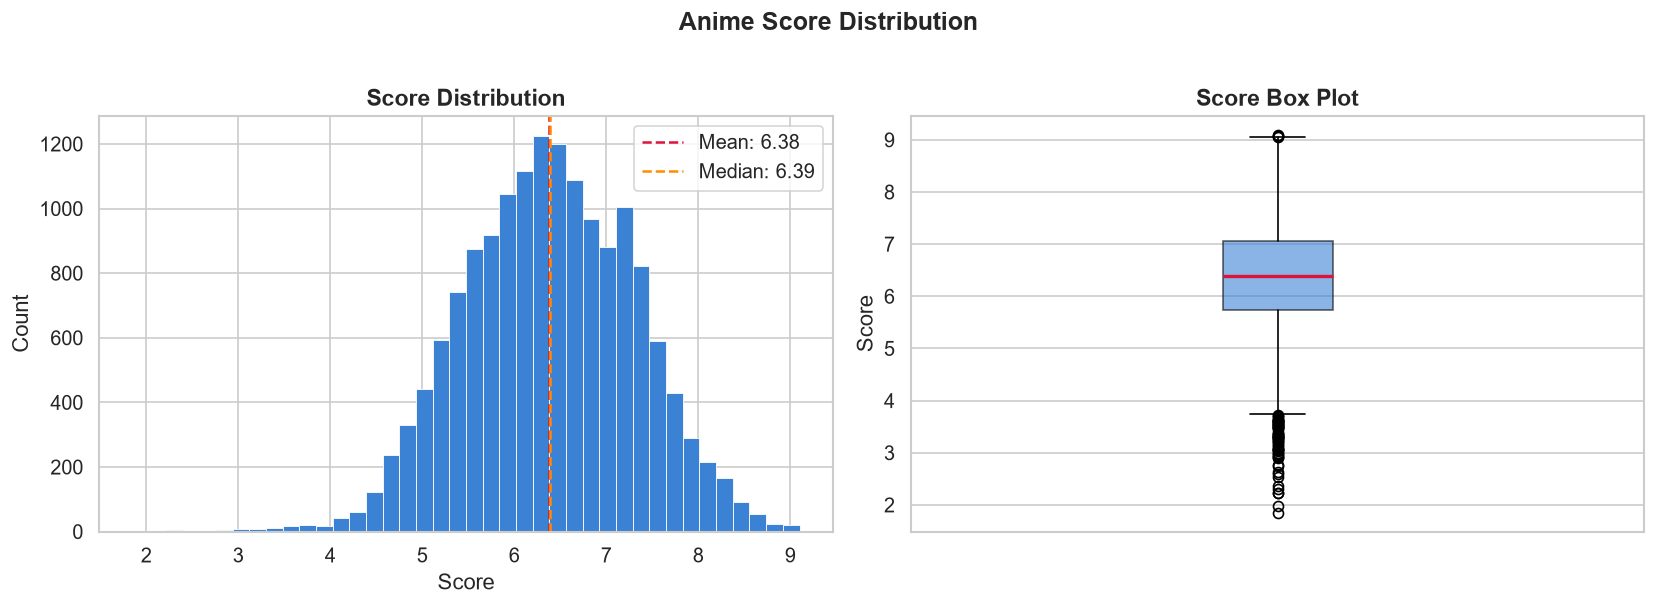

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(scored, bins=40, color=ACCENT, edgecolor='white', linewidth=0.5)
axes[0].axvline(scored.mean(), color='crimson', linestyle='--', linewidth=1.5, label=f'Mean: {scored.mean():.2f}')
axes[0].axvline(scored.median(), color='darkorange', linestyle='--', linewidth=1.5, label=f'Median: {scored.median():.2f}')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution')
axes[0].legend()

# Box plot
axes[1].boxplot(scored, vert=True, patch_artist=True,
                boxprops=dict(facecolor=ACCENT, alpha=0.6),
                medianprops=dict(color='crimson', linewidth=2))
axes[1].set_ylabel('Score')
axes[1].set_title('Score Box Plot')
axes[1].set_xticks([])

plt.suptitle('Anime Score Distribution', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('score_distribution.png', bbox_inches='tight')
plt.show()

In [11]:
# ── 4.2  Top 15 highest-scored anime (min 1000 scored-by voters) ──────────────
top_scored = (
    df[df['Scored By'] >= 1000]
    .nlargest(15, 'Score')[['Name', 'Score', 'Scored By', 'Type', 'Premiered']]
    .reset_index(drop=True)
)
print('Top 15 Highest-Scored Anime (≥1,000 voters):')
top_scored

Top 15 Highest-Scored Anime (≥1,000 voters):


,Name,Score,Scored By,Type,Premiered
0,Fullmetal Alchemist: Brotherhood,9.10,2020030.0,TV,spring 2009
1,Steins;Gate,9.07,1336233.0,TV,spring 2011
2,Bleach: Sennen Kessen-hen,9.07,213872.0,TV,fall 2022
3,Gintama°,9.06,237957.0,TV,spring 2015
4,Shingeki no Kyojin Season 3 Part 2,9.05,1471825.0,TV,spring 2019
5,Kaguya-sama wa Kokurasetai: Ultra Romantic,9.05,451187.0,TV,spring 2022
6,Shingeki no Kyojin: The Final Season - Kankets...,9.05,155773.0,Special,NaN
7,Gintama',9.04,226175.0,TV,spring 2011
8,Hunter x Hunter (2011),9.04,1651790.0,TV,fall 2011
9,Gintama: The Final,9.04,63628.0,Movie,NaN


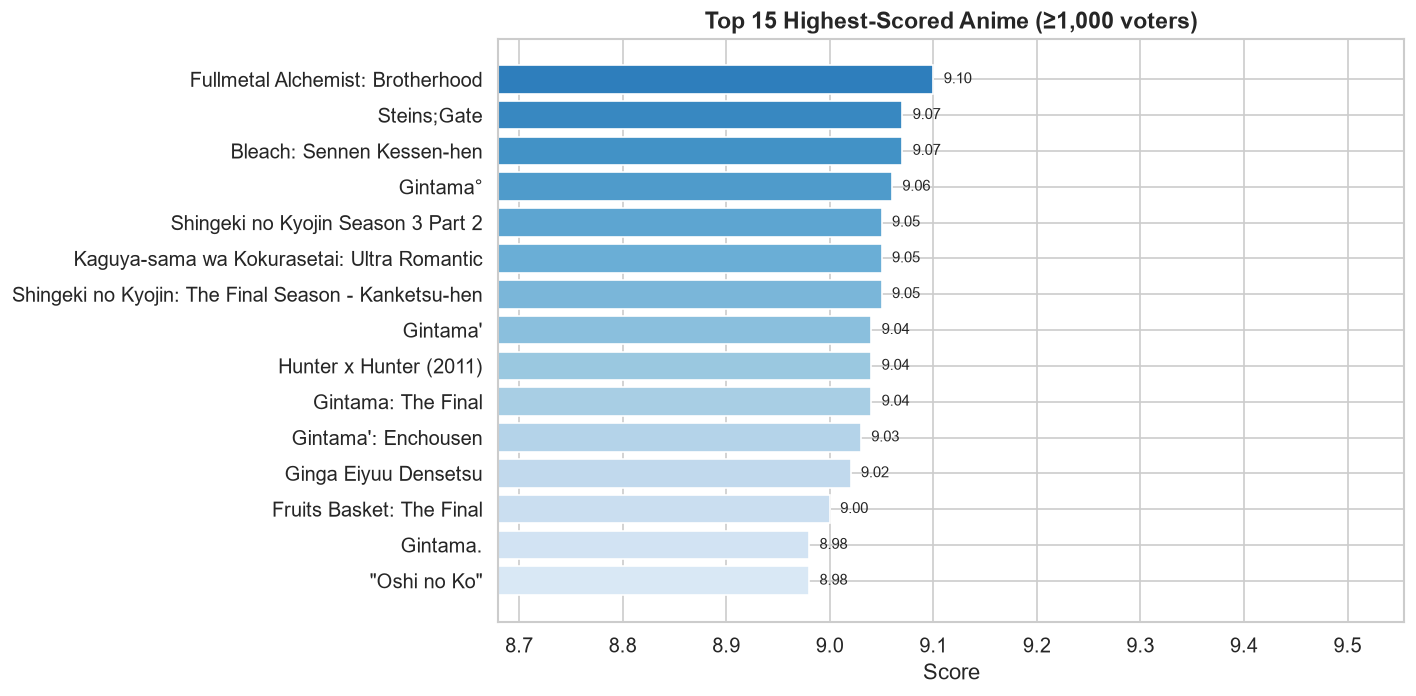

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Blues_r(np.linspace(0.3, 0.85, len(top_scored)))
bars = ax.barh(top_scored['Name'][::-1], top_scored['Score'][::-1], color=colors[::-1])
ax.set_xlabel('Score')
ax.set_title('Top 15 Highest-Scored Anime (≥1,000 voters)')
ax.set_xlim(left=top_scored['Score'].min() - 0.3)
for bar, score in zip(bars, top_scored['Score'][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_scored_anime.png', bbox_inches='tight')
plt.show()

In [13]:
# ── 4.3  Score by Type ────────────────────────────────────────────────────────
score_by_type = (
    df[df['Score'].notna() & df['Type'].notna()]
    .groupby('Type')['Score']
    .agg(['mean', 'median', 'count'])
    .round(3)
    .sort_values('median', ascending=False)
)
print('Score statistics by Type:')
score_by_type

Score statistics by Type:


,mean,median,count
Type,,,
TV,6.847,6.86,4482
Movie,6.344,6.37,2475
Special,6.366,6.37,2039
OVA,6.218,6.22,3283
ONA,6.038,6.00,1929
Music,5.861,5.77,1483


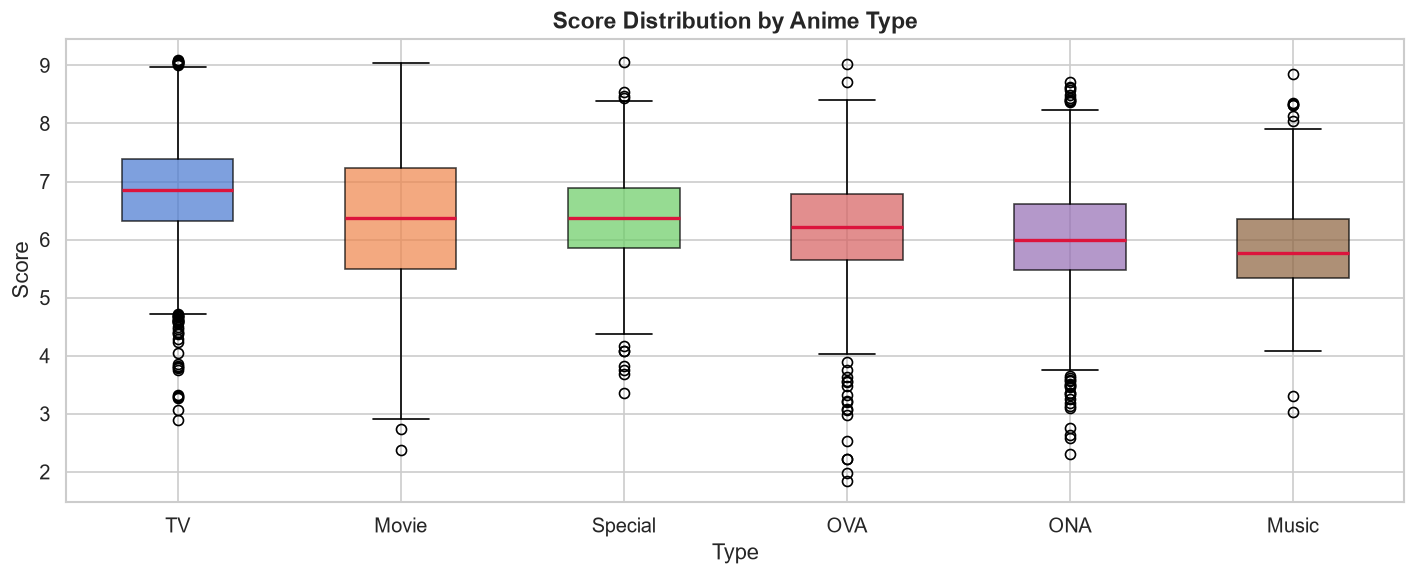

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
type_order = score_by_type.index.tolist()
data_for_box = [df[df['Type'] == t]['Score'].dropna().values for t in type_order]
bp = ax.boxplot(data_for_box, tick_labels=type_order, patch_artist=True,
                medianprops=dict(color='crimson', linewidth=2))
palette = sns.color_palette('muted', len(type_order))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xlabel('Type')
ax.set_ylabel('Score')
ax.set_title('Score Distribution by Anime Type')
plt.tight_layout()
plt.savefig('score_by_type.png', bbox_inches='tight')
plt.show()

---
## 5. Popularity & Engagement Analysis

In [15]:
# ── 5.1  Distributions of Members, Favorites, Popularity ─────────────────────
eng_cols = ['Members', 'Favorites', 'Popularity']
print('Engagement metrics — summary:')
df[eng_cols].describe().round(2)

Engagement metrics — summary:


,Members,Favorites,Popularity
count,24905.00,24905.00,24905.00
mean,37104.96,432.60,12265.39
std,156825.24,4353.18,7187.43
min,0.00,0.00,0.00
25%,209.00,0.00,6040.00
50%,1056.00,1.00,12265.00
75%,9326.00,18.00,18491.00
max,3744541.00,217606.00,24723.00


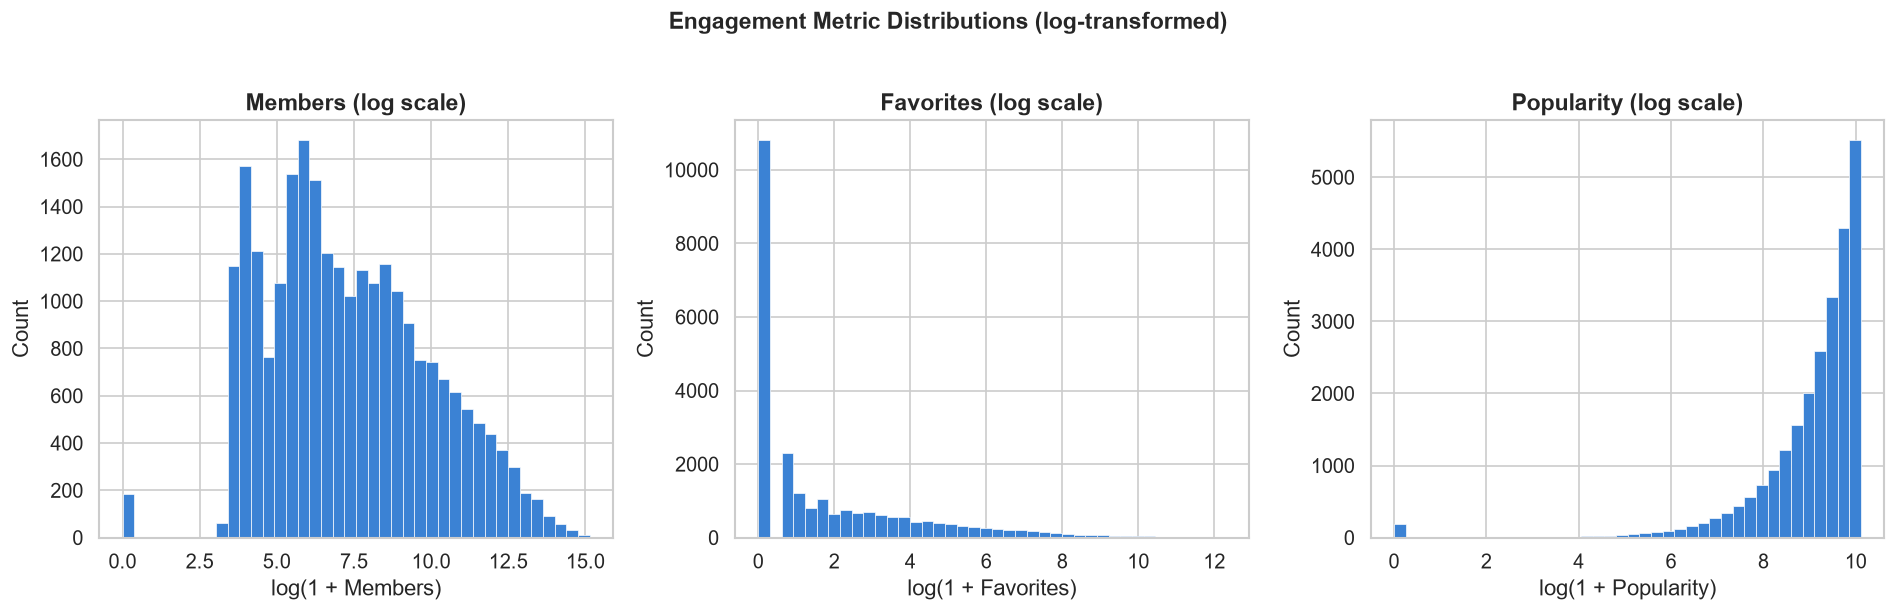

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, eng_cols):
    data = df[col].dropna()
    # log scale where appropriate
    log_data = np.log1p(data)
    ax.hist(log_data, bins=40, color=ACCENT, edgecolor='white', linewidth=0.4)
    ax.set_title(f'{col} (log scale)')
    ax.set_xlabel(f'log(1 + {col})')
    ax.set_ylabel('Count')
plt.suptitle('Engagement Metric Distributions (log-transformed)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('engagement_distributions.png', bbox_inches='tight')
plt.show()

In [17]:
# ── 5.2  Top 15 by Members ────────────────────────────────────────────────────
top_members = (
    df.nlargest(15, 'Members')[['Name', 'Members', 'Score', 'Type']]
    .reset_index(drop=True)
)
print('Top 15 Anime by Members:')
top_members

Top 15 Anime by Members:


,Name,Members,Score,Type
0,Shingeki no Kyojin,3744541,8.54,TV
1,Death Note,3713315,8.62,TV
2,Fullmetal Alchemist: Brotherhood,3176556,9.10,TV
3,One Punch Man,3058666,8.50,TV
4,Sword Art Online,2951821,7.20,TV
5,Boku no Hero Academia,2882333,7.89,TV
6,Kimetsu no Yaiba,2808712,8.50,TV
7,Naruto,2717330,7.99,TV
8,Tokyo Ghoul,2699241,7.79,TV
9,Hunter x Hunter (2011),2656870,9.04,TV


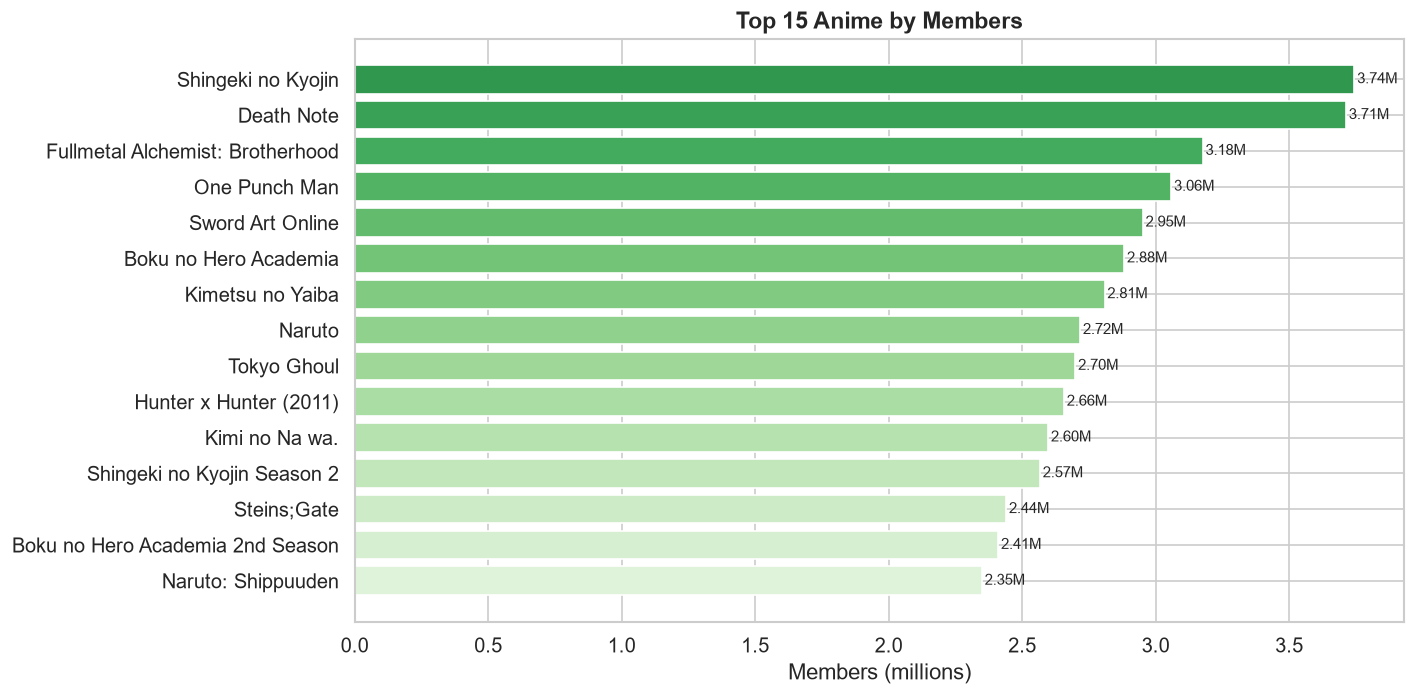

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Greens_r(np.linspace(0.3, 0.85, len(top_members)))
bars = ax.barh(top_members['Name'][::-1], top_members['Members'][::-1] / 1e6, color=colors[::-1])
ax.set_xlabel('Members (millions)')
ax.set_title('Top 15 Anime by Members')
for bar, val in zip(bars, top_members['Members'][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val/1e6:.2f}M', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_members.png', bbox_inches='tight')
plt.show()

In [19]:
# ── 5.3  Top 15 by Favorites ──────────────────────────────────────────────────
top_fav = (
    df.nlargest(15, 'Favorites')[['Name', 'Favorites', 'Score', 'Type']]
    .reset_index(drop=True)
)
print('Top 15 Anime by Favorites:')
top_fav

Top 15 Anime by Favorites:


,Name,Favorites,Score,Type
0,Fullmetal Alchemist: Brotherhood,217606,9.10,TV
1,Hunter x Hunter (2011),200265,9.04,TV
2,One Piece,198986,8.69,TV
3,Steins;Gate,182964,9.07,TV
4,Death Note,167586,8.62,TV
5,Shingeki no Kyojin,163844,8.54,TV
6,Naruto: Shippuuden,107735,8.26,TV
7,Code Geass: Hangyaku no Lelouch,105379,8.70,TV
8,Neon Genesis Evangelion,100638,8.35,TV
9,Kimetsu no Yaiba,88375,8.50,TV


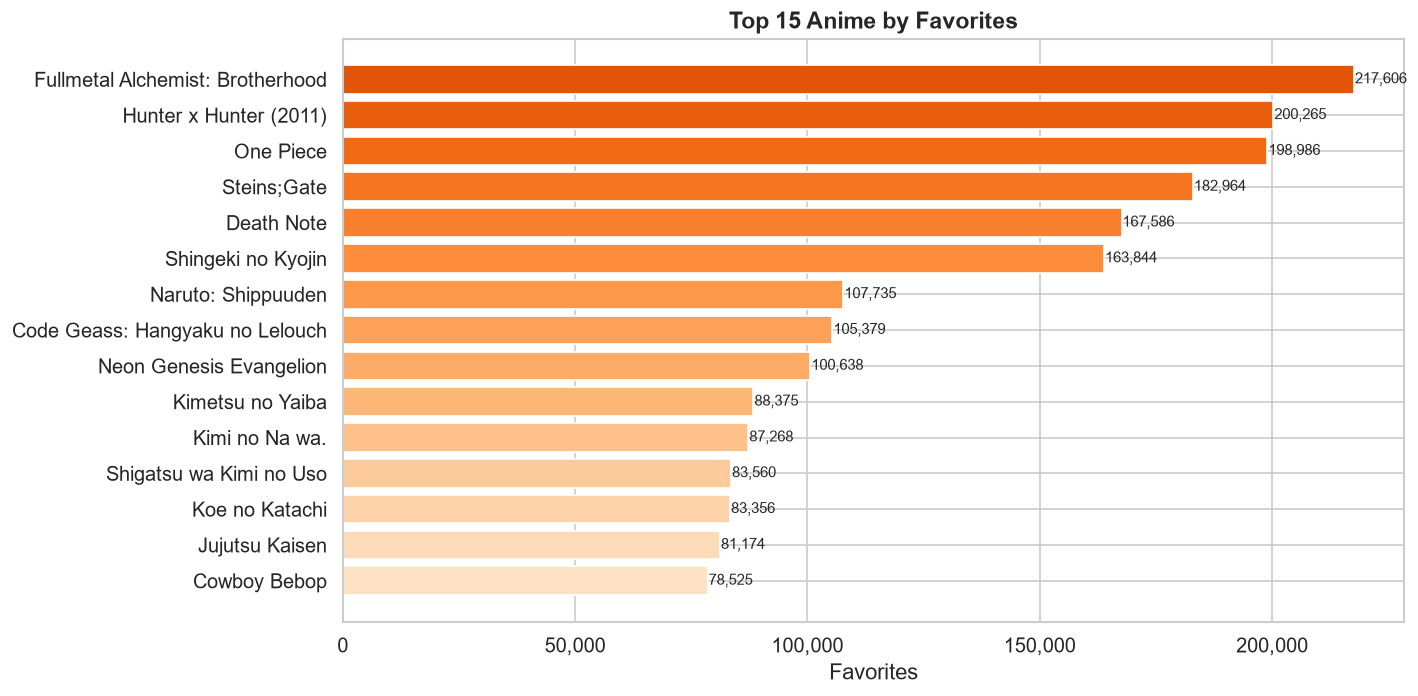

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Oranges_r(np.linspace(0.3, 0.85, len(top_fav)))
bars = ax.barh(top_fav['Name'][::-1], top_fav['Favorites'][::-1], color=colors[::-1])
ax.set_xlabel('Favorites')
ax.set_title('Top 15 Anime by Favorites')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars, top_fav['Favorites'][::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_favorites.png', bbox_inches='tight')
plt.show()

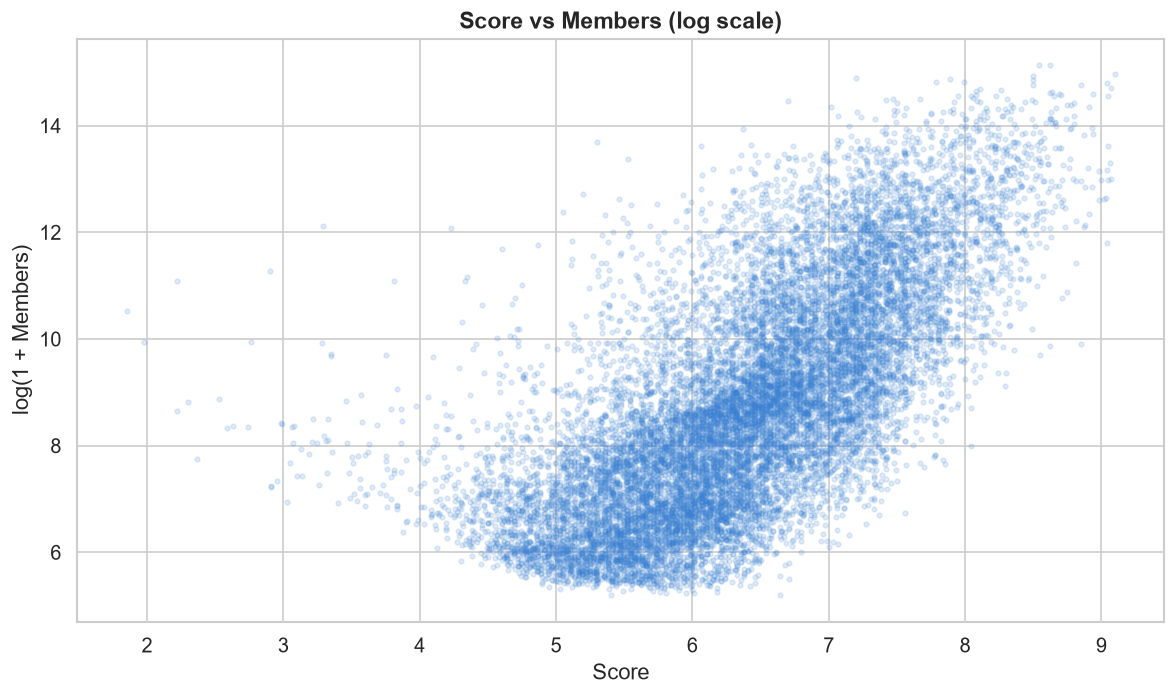

In [21]:
# ── 5.4  Score vs Members scatter ────────────────────────────────────────────
plot_df = df[df['Score'].notna() & (df['Members'] > 0)].copy()

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    plot_df['Score'],
    np.log1p(plot_df['Members']),
    alpha=0.15, s=8, c=ACCENT
)
ax.set_xlabel('Score')
ax.set_ylabel('log(1 + Members)')
ax.set_title('Score vs Members (log scale)')
plt.tight_layout()
plt.savefig('score_vs_members.png', bbox_inches='tight')
plt.show()

---
## 6. Genre Analysis

In [22]:
# ── 6.1  Explode genres into individual rows ──────────────────────────────────
genre_df = (
    df[df['Genres'].notna()]
    .assign(Genre=lambda x: x['Genres'].str.split(', '))
    .explode('Genre')
    [['anime_id', 'Name', 'Score', 'Members', 'Favorites', 'Type', 'Genre']]
    .copy()
)
genre_df['Genre'] = genre_df['Genre'].str.strip()

genre_counts = genre_df['Genre'].value_counts().reset_index()
genre_counts.columns = ['Genre', 'Count']

print(f'Unique genres after exploding: {genre_df["Genre"].nunique()}')
print('Top 20 genres by frequency:')
genre_counts.head(20)

Unique genres after exploding: 21
Top 20 genres by frequency:


,Genre,Count
0,Comedy,7142
1,Fantasy,5306
2,Action,4730
3,Adventure,3842
4,Sci-Fi,3091
5,Drama,2836
6,Romance,2063
7,Slice of Life,1755
8,Supernatural,1494
9,Hentai,1486


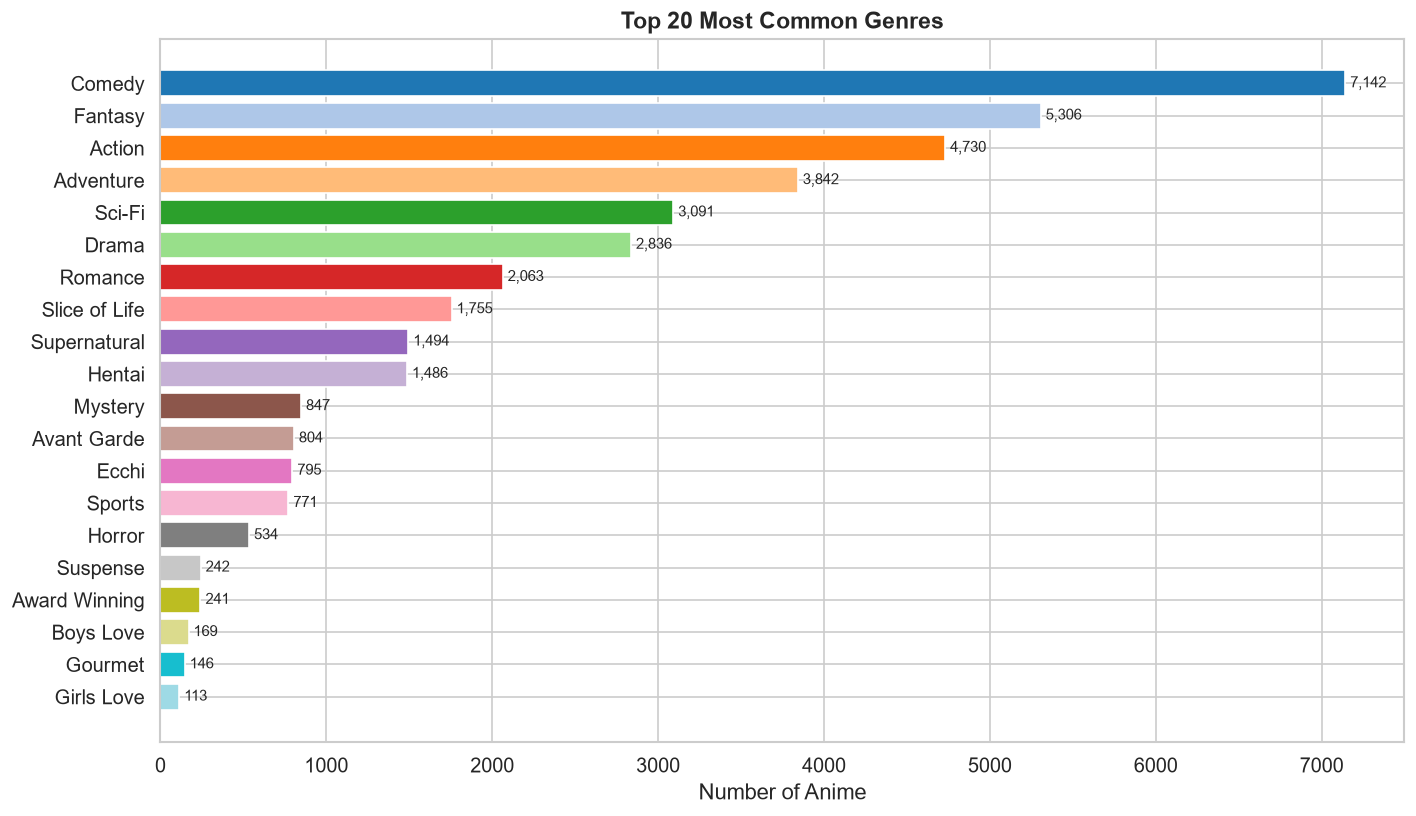

In [23]:
top20_genres = genre_counts.head(20)

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.tab20(np.linspace(0, 1, len(top20_genres)))
bars = ax.barh(top20_genres['Genre'][::-1], top20_genres['Count'][::-1], color=colors[::-1])
ax.set_xlabel('Number of Anime')
ax.set_title('Top 20 Most Common Genres')
for bar, val in zip(bars, top20_genres['Count'][::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_genres.png', bbox_inches='tight')
plt.show()

In [24]:
# ── 6.2  Average score by genre (top 20 by count) ────────────────────────────
genre_score = (
    genre_df[genre_df['Score'].notna()]
    .groupby('Genre')
    .agg(Avg_Score=('Score', 'mean'), Count=('Score', 'count'))
    .reset_index()
)
# Only genres with ≥50 scored titles
genre_score = genre_score[genre_score['Count'] >= 50].sort_values('Avg_Score', ascending=False)
print('Top 20 genres by average score (≥50 titled):')
genre_score.head(20)

Top 20 genres by average score (≥50 titled):


,Genre,Avg_Score,Count
3,Award Winning,7.296308,214
14,Mystery,6.995093,752
20,Suspense,6.962963,189
6,Drama,6.850645,2200
15,Romance,6.804509,1832
19,Supernatural,6.744600,1274
18,Sports,6.722046,567
0,Action,6.674112,3957
1,Adventure,6.673997,2672
11,Gourmet,6.627664,107


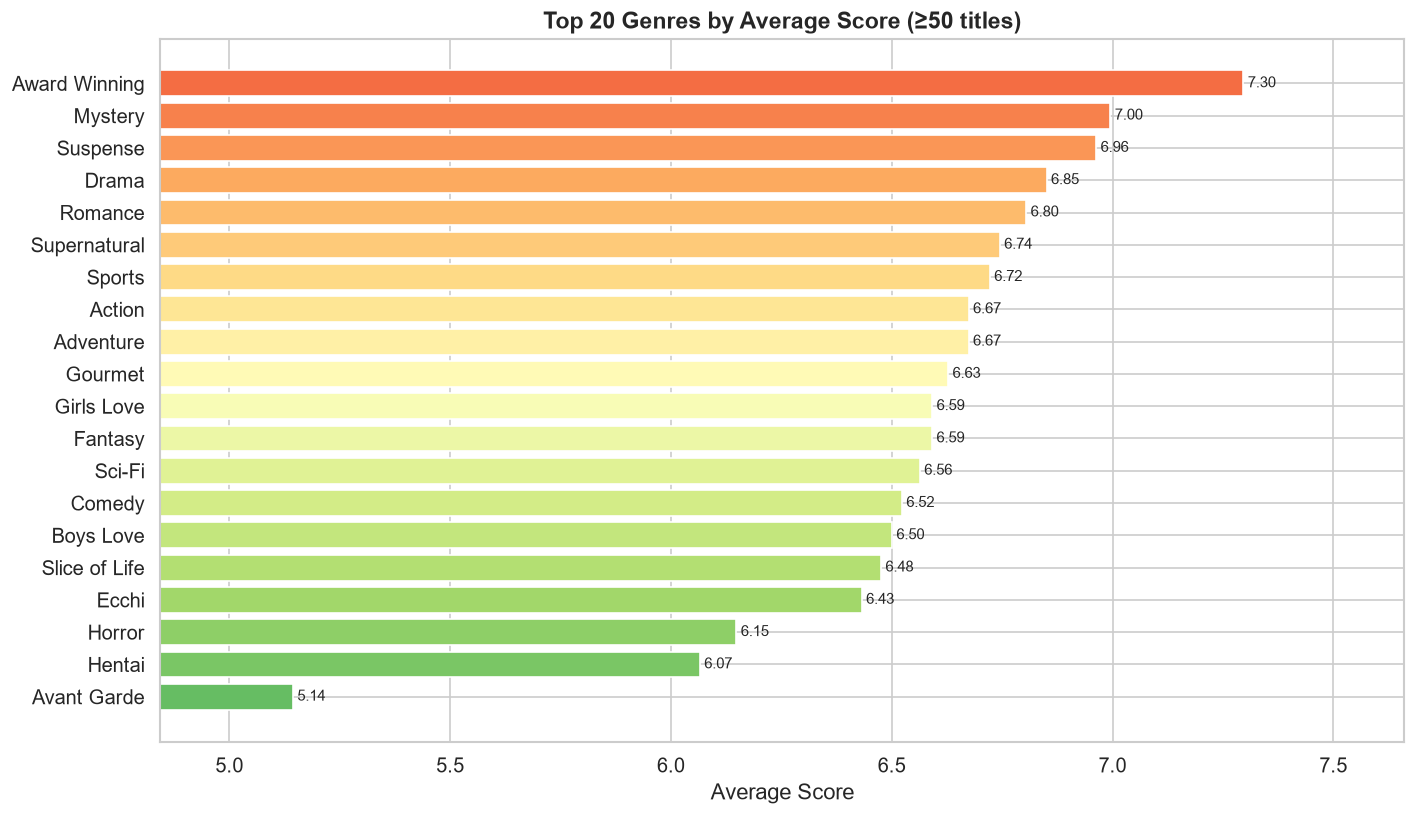

In [25]:
top20_gs = genre_score.head(20)

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(top20_gs)))
bars = ax.barh(top20_gs['Genre'][::-1], top20_gs['Avg_Score'][::-1], color=colors[::-1])
ax.set_xlabel('Average Score')
ax.set_title('Top 20 Genres by Average Score (≥50 titles)')
ax.set_xlim(left=top20_gs['Avg_Score'].min() - 0.3)
for bar, val in zip(bars, top20_gs['Avg_Score'][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('genre_avg_score.png', bbox_inches='tight')
plt.show()

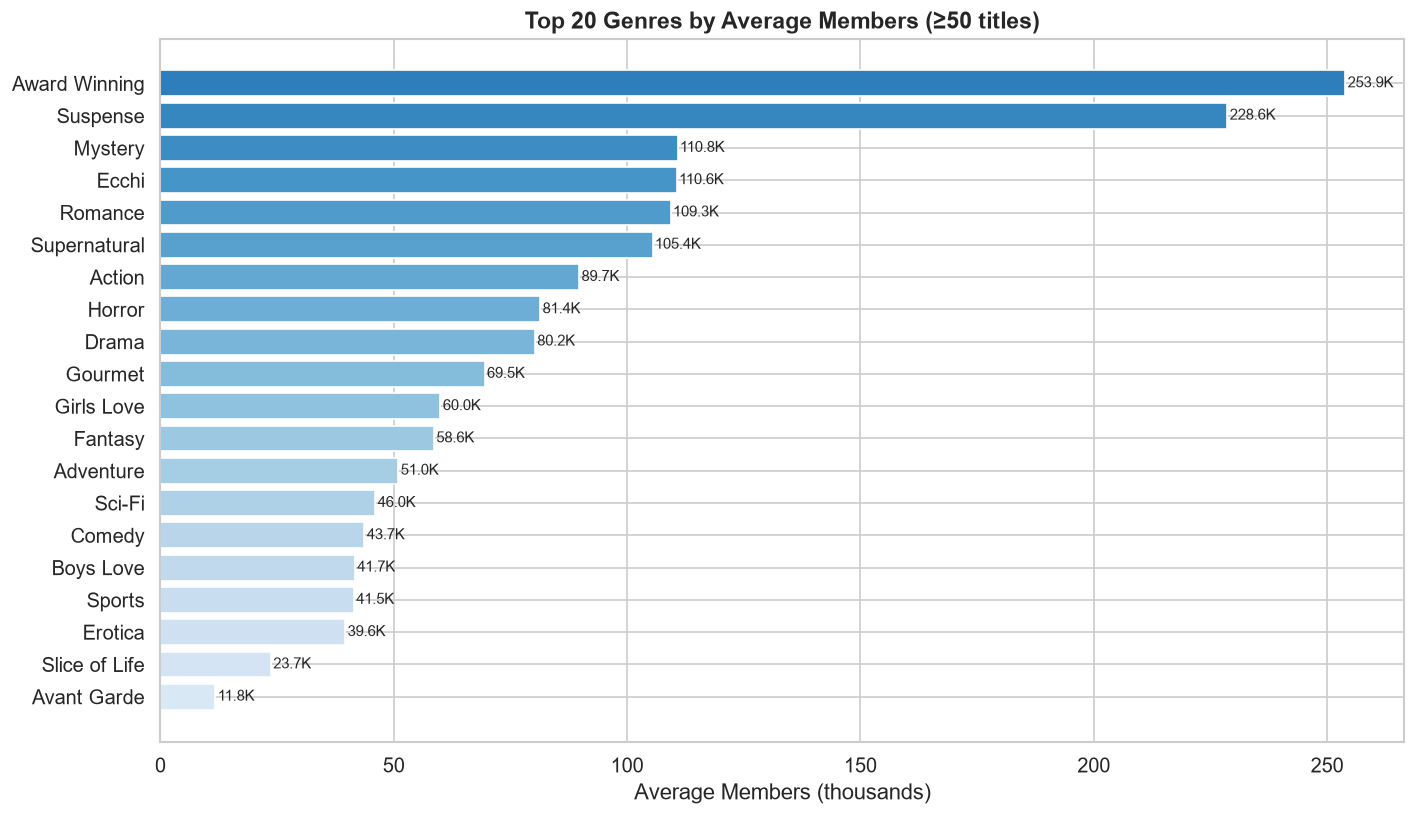

In [26]:
# ── 6.3  Average Members by genre ────────────────────────────────────────────
genre_members = (
    genre_df[genre_df['Members'] > 0]
    .groupby('Genre')['Members']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'Avg_Members', 'count': 'Count'})
)
genre_members = genre_members[genre_members['Count'] >= 50].sort_values('Avg_Members', ascending=False)

top20_gm = genre_members.head(20)
fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.Blues_r(np.linspace(0.3, 0.85, len(top20_gm)))
bars = ax.barh(top20_gm['Genre'][::-1], top20_gm['Avg_Members'][::-1] / 1000, color=colors[::-1])
ax.set_xlabel('Average Members (thousands)')
ax.set_title('Top 20 Genres by Average Members (≥50 titles)')
for bar, val in zip(bars, top20_gm['Avg_Members'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val/1000:.1f}K', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('genre_avg_members.png', bbox_inches='tight')
plt.show()

---
## 7. Anime Type Analysis

In [27]:
# ── 7.1  Type distribution ────────────────────────────────────────────────────
type_counts = df['Type'].value_counts().reset_index()
type_counts.columns = ['Type', 'Count']
print('Anime count by Type:')
type_counts

Anime count by Type:


,Type,Count
0,TV,7597
1,Movie,4381
2,OVA,4076
3,ONA,3533
4,Music,2686
5,Special,2558


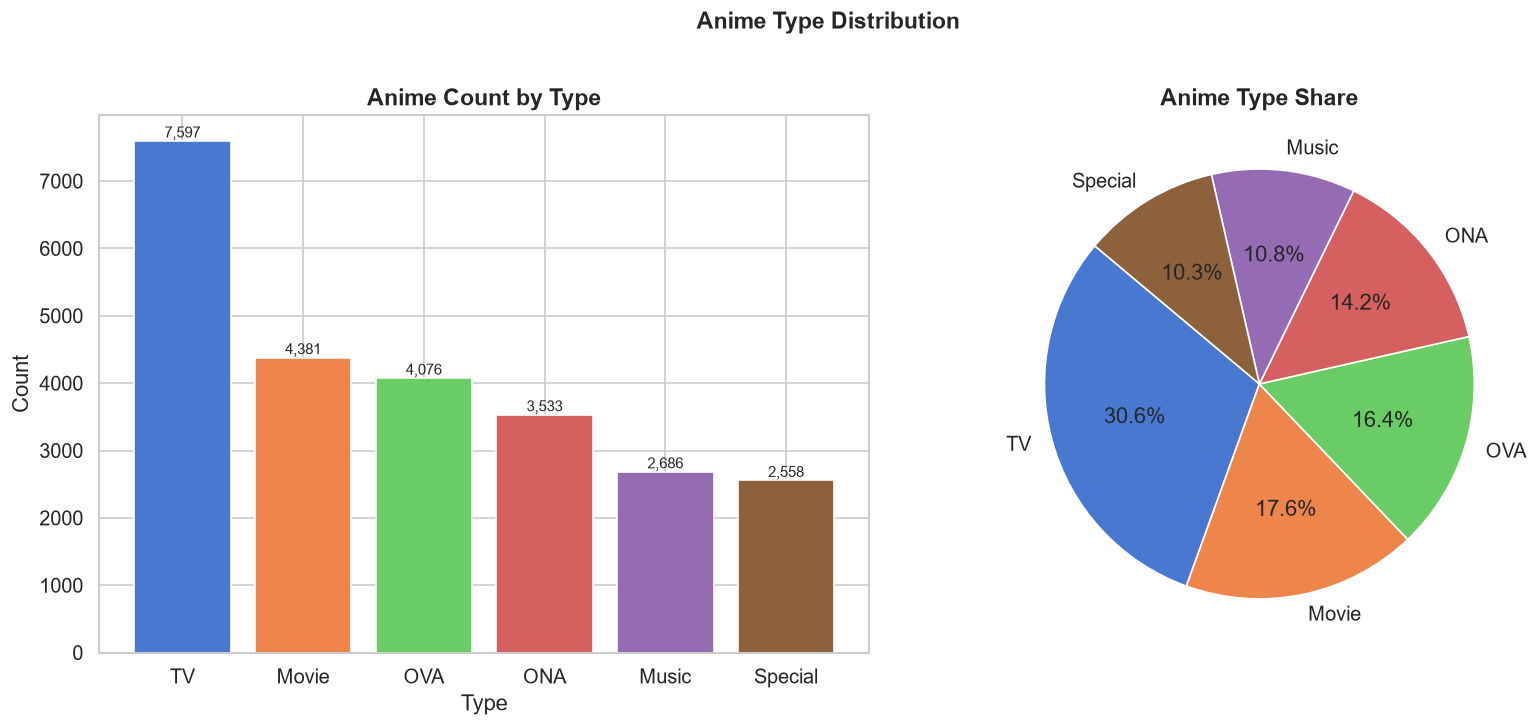

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
palette = sns.color_palette('muted', len(type_counts))
axes[0].bar(type_counts['Type'], type_counts['Count'], color=palette)
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Count')
axes[0].set_title('Anime Count by Type')
for i, (t, c) in enumerate(zip(type_counts['Type'], type_counts['Count'])):
    axes[0].text(i, c + 50, f'{c:,}', ha='center', fontsize=9)

# Pie chart (exclude UNKNOWN/NaN)
tc_pie = type_counts[type_counts['Type'].notna()]
axes[1].pie(tc_pie['Count'], labels=tc_pie['Type'], autopct='%1.1f%%',
            colors=palette, startangle=140)
axes[1].set_title('Anime Type Share')

plt.suptitle('Anime Type Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('type_distribution.png', bbox_inches='tight')
plt.show()

In [29]:
# ── 7.2  Members by Type ──────────────────────────────────────────────────────
type_members = (
    df[df['Type'].notna()]
    .groupby('Type')['Members']
    .agg(['mean', 'median', 'sum', 'count'])
    .round(0)
    .sort_values('median', ascending=False)
)
print('Members statistics by Type:')
type_members

Members statistics by Type:


,mean,median,sum,count
Type,,,,
OVA,13514.0,3482.0,55081353,4076
TV,92545.0,2967.0,703066787,7597
Special,14427.0,2944.0,36904694,2558
Movie,23075.0,590.0,101091169,4381
ONA,7048.0,528.0,24900034,3533
Music,977.0,252.0,2623489,2686


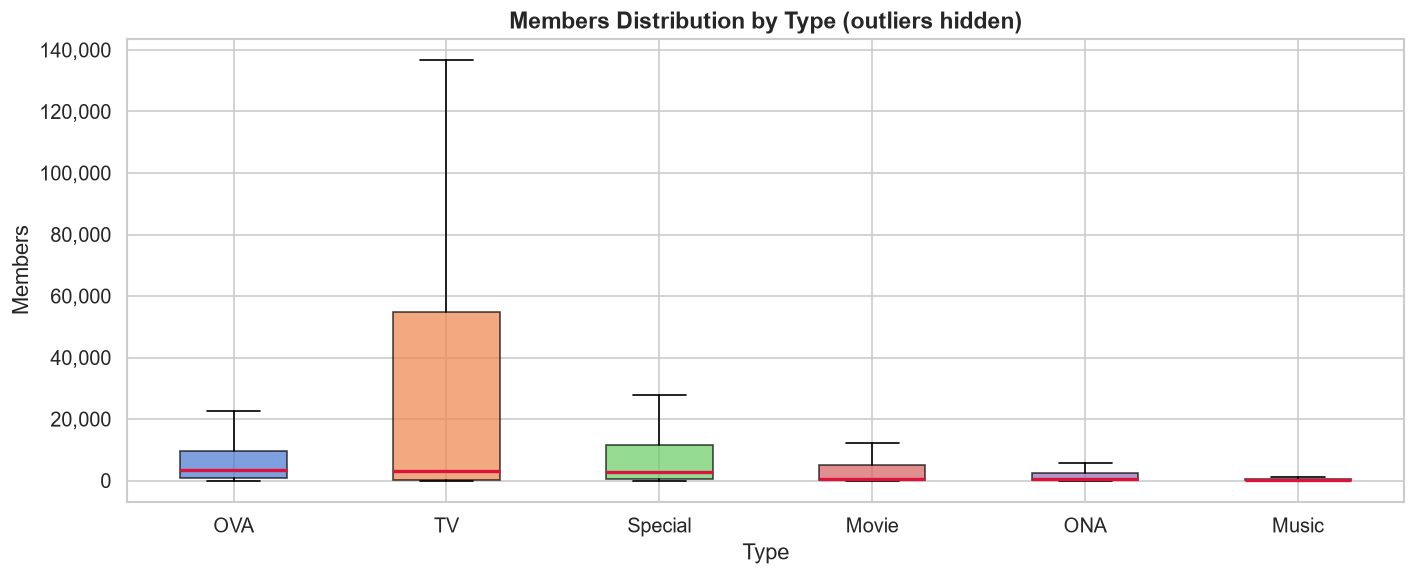

In [30]:
type_order_m = type_members.index.tolist()
fig, ax = plt.subplots(figsize=(12, 5))
data_for_box = [df[df['Type'] == t]['Members'].dropna().values for t in type_order_m]
bp = ax.boxplot(data_for_box, tick_labels=type_order_m, patch_artist=True,
                medianprops=dict(color='crimson', linewidth=2),
                showfliers=False)  # hide extreme outliers for readability
palette2 = sns.color_palette('muted', len(type_order_m))
for patch, color in zip(bp['boxes'], palette2):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xlabel('Type')
ax.set_ylabel('Members')
ax.set_title('Members Distribution by Type (outliers hidden)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('members_by_type.png', bbox_inches='tight')
plt.show()

---
## 8. Studio Analysis

In [31]:
# ── 8.1  Explode studios ──────────────────────────────────────────────────────
studio_df = (
    df[df['Studios'].notna()]
    .assign(Studio=lambda x: x['Studios'].str.split(', '))
    .explode('Studio')
    [['anime_id', 'Name', 'Score', 'Members', 'Favorites', 'Type', 'Studio']]
    .copy()
)
studio_df['Studio'] = studio_df['Studio'].str.strip()

studio_counts = studio_df['Studio'].value_counts().reset_index()
studio_counts.columns = ['Studio', 'Count']

print(f'Unique studios: {studio_df["Studio"].nunique()}')
print('Top 20 studios by number of anime:')
studio_counts.head(20)

Unique studios: 1043
Top 20 studios by number of anime:


,Studio,Count
0,Toei Animation,864
1,Sunrise,552
2,J.C.Staff,408
3,Madhouse,371
4,Production I.G,346
5,TMS Entertainment,341
6,Shanghai Animation Film Studio,336
7,Studio Deen,312
8,OLM,283
9,Pierrot,279


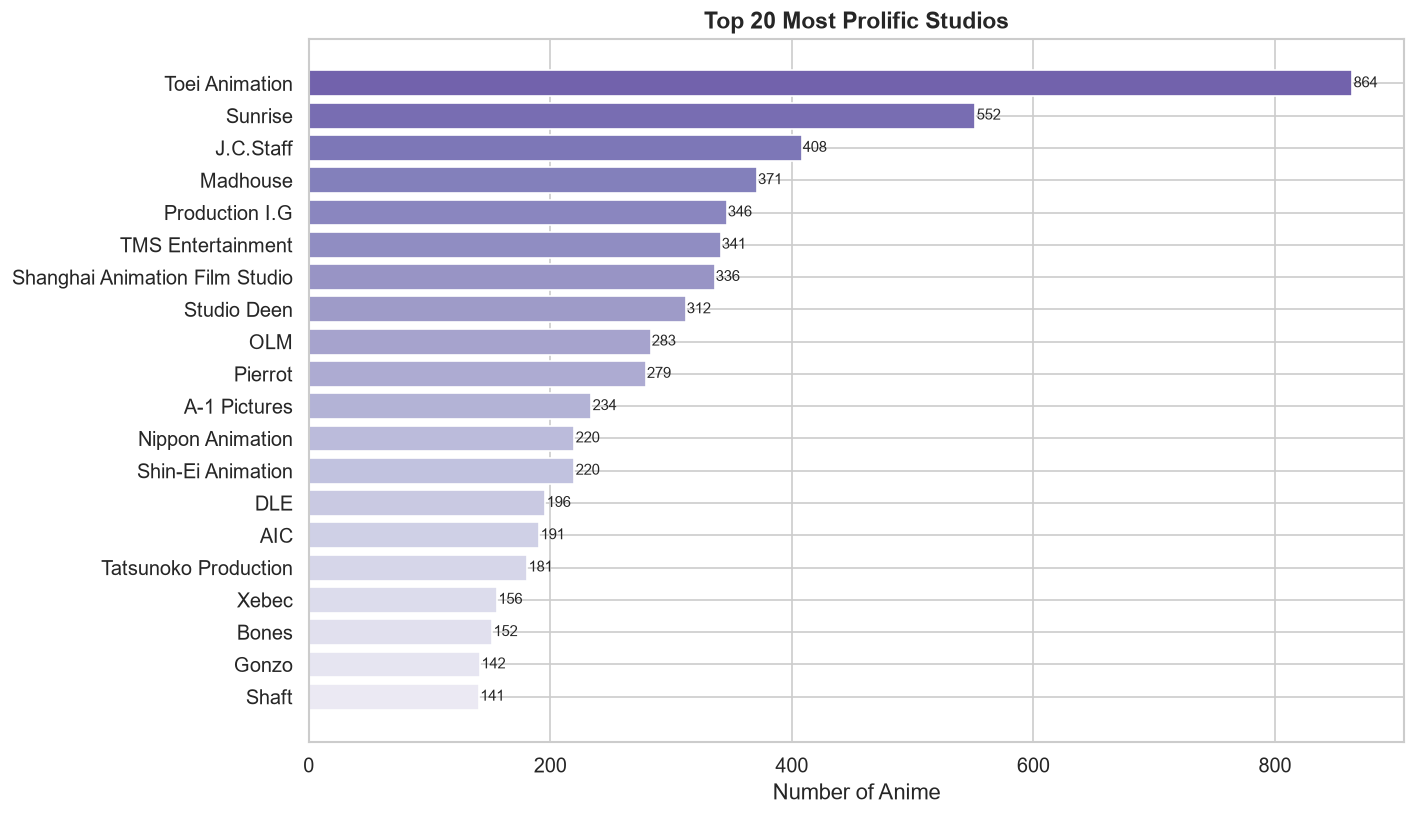

In [32]:
top20_studios = studio_counts.head(20)

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.Purples_r(np.linspace(0.3, 0.85, len(top20_studios)))
bars = ax.barh(top20_studios['Studio'][::-1], top20_studios['Count'][::-1], color=colors[::-1])
ax.set_xlabel('Number of Anime')
ax.set_title('Top 20 Most Prolific Studios')
for bar, val in zip(bars, top20_studios['Count'][::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_studios_count.png', bbox_inches='tight')
plt.show()

In [33]:
# ── 8.2  Top studios by average score (min 10 scored titles) ─────────────────
studio_score = (
    studio_df[studio_df['Score'].notna()]
    .groupby('Studio')
    .agg(Avg_Score=('Score', 'mean'), Count=('Score', 'count'))
    .reset_index()
)
studio_score = studio_score[studio_score['Count'] >= 10].sort_values('Avg_Score', ascending=False)
print('Top 20 studios by average score (≥10 scored titles):')
studio_score.head(20)

Top 20 studios by average score (≥10 scored titles):


,Studio,Avg_Score,Count
52,Animation Do,7.633000,10
455,Motion Magic,7.629091,11
638,Shuka,7.608947,19
109,Bones,7.323919,148
380,Kyoto Animation,7.315952,126
262,Geno Studio,7.295000,10
788,TROYCA,7.289474,19
175,David Production,7.267556,45
545,Platinum Vision,7.241000,10
863,White Fox,7.234889,45


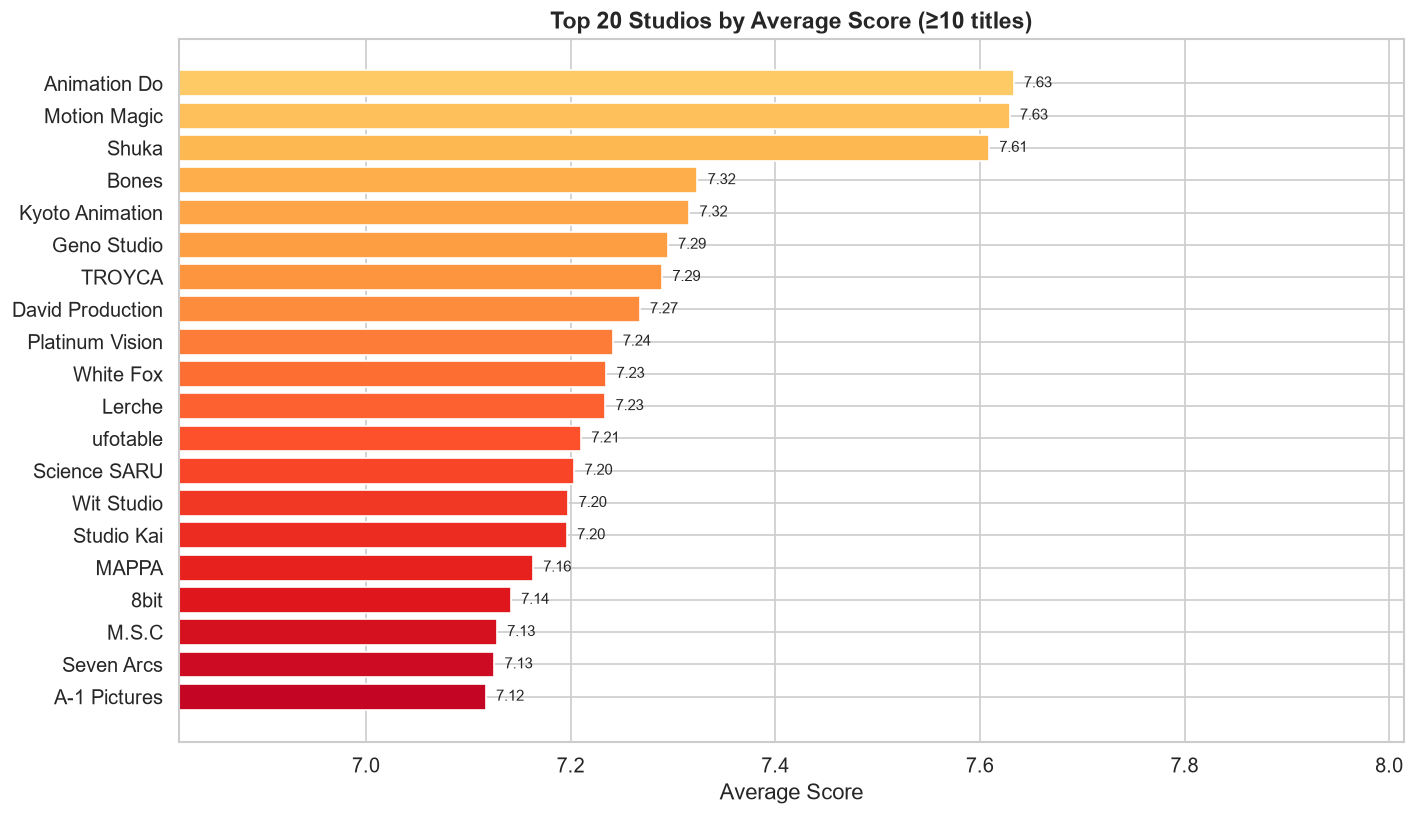

In [34]:
top20_ss = studio_score.head(20)

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.85, len(top20_ss)))
bars = ax.barh(top20_ss['Studio'][::-1], top20_ss['Avg_Score'][::-1], color=colors[::-1])
ax.set_xlabel('Average Score')
ax.set_title('Top 20 Studios by Average Score (≥10 titles)')
ax.set_xlim(left=top20_ss['Avg_Score'].min() - 0.3)
for bar, val in zip(bars, top20_ss['Avg_Score'][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('studio_avg_score.png', bbox_inches='tight')
plt.show()

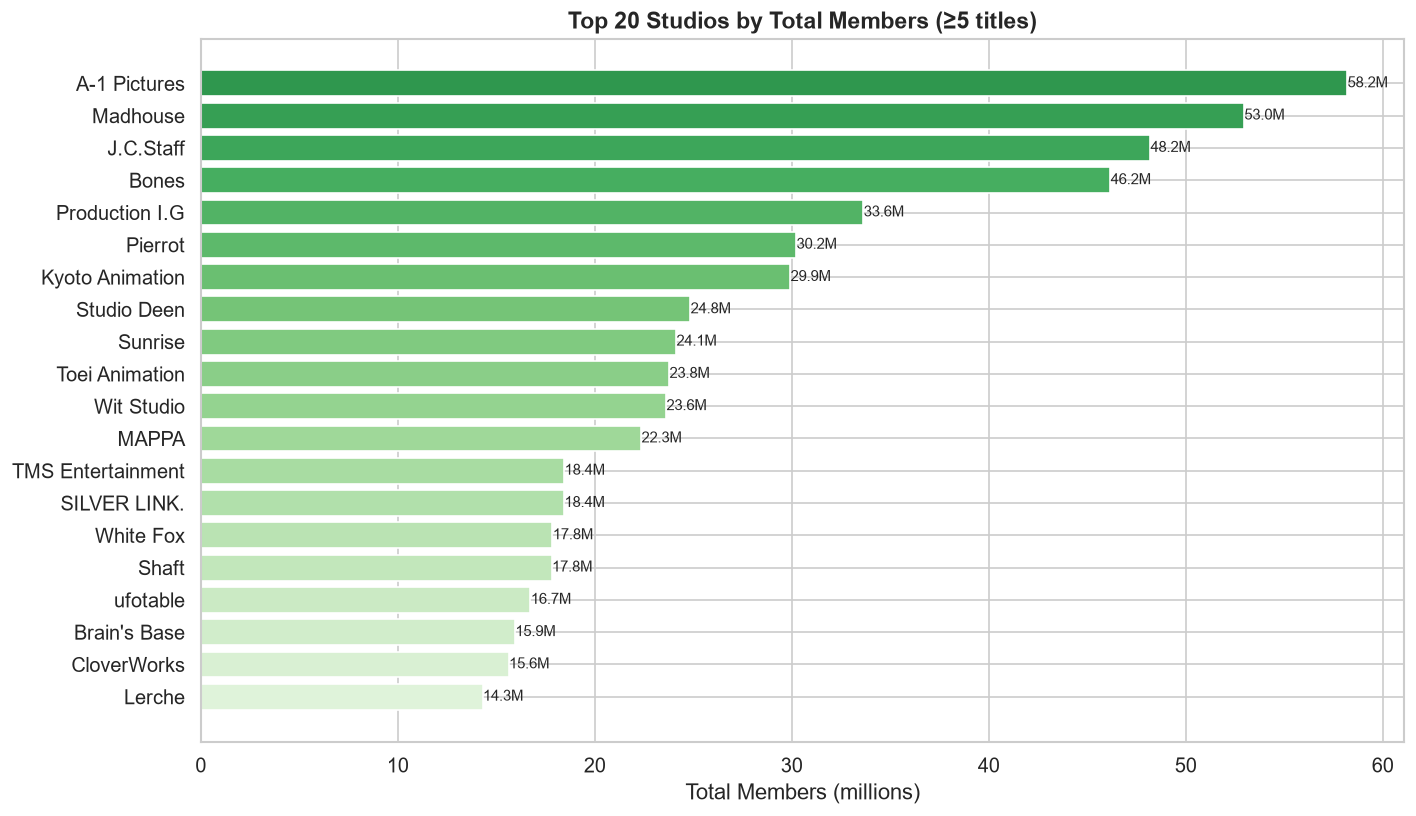

In [35]:
# ── 8.3  Top studios by total Members ────────────────────────────────────────
studio_members = (
    studio_df[studio_df['Members'] > 0]
    .groupby('Studio')['Members']
    .agg(['sum', 'mean', 'count'])
    .reset_index()
    .rename(columns={'sum': 'Total_Members', 'mean': 'Avg_Members', 'count': 'Count'})
)
studio_members = studio_members[studio_members['Count'] >= 5].sort_values('Total_Members', ascending=False)

top20_sm = studio_members.head(20)
fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.Greens_r(np.linspace(0.3, 0.85, len(top20_sm)))
bars = ax.barh(top20_sm['Studio'][::-1], top20_sm['Total_Members'][::-1] / 1e6, color=colors[::-1])
ax.set_xlabel('Total Members (millions)')
ax.set_title('Top 20 Studios by Total Members (≥5 titles)')
for bar, val in zip(bars, top20_sm['Total_Members'][::-1]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val/1e6:.1f}M', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('studio_total_members.png', bbox_inches='tight')
plt.show()

---
## 9. Source Analysis

In [36]:
# ── 9.1  Source distribution ──────────────────────────────────────────────────
source_counts = df['Source'].value_counts().reset_index()
source_counts.columns = ['Source', 'Count']
print('Anime count by Source:')
source_counts

Anime count by Source:


,Source,Count
0,Original,9622
1,Manga,4687
2,Game,1232
3,Visual novel,1107
4,Other,1008
5,Light novel,968
6,Novel,709
7,Web manga,447
8,Music,395
9,4-koma manga,314


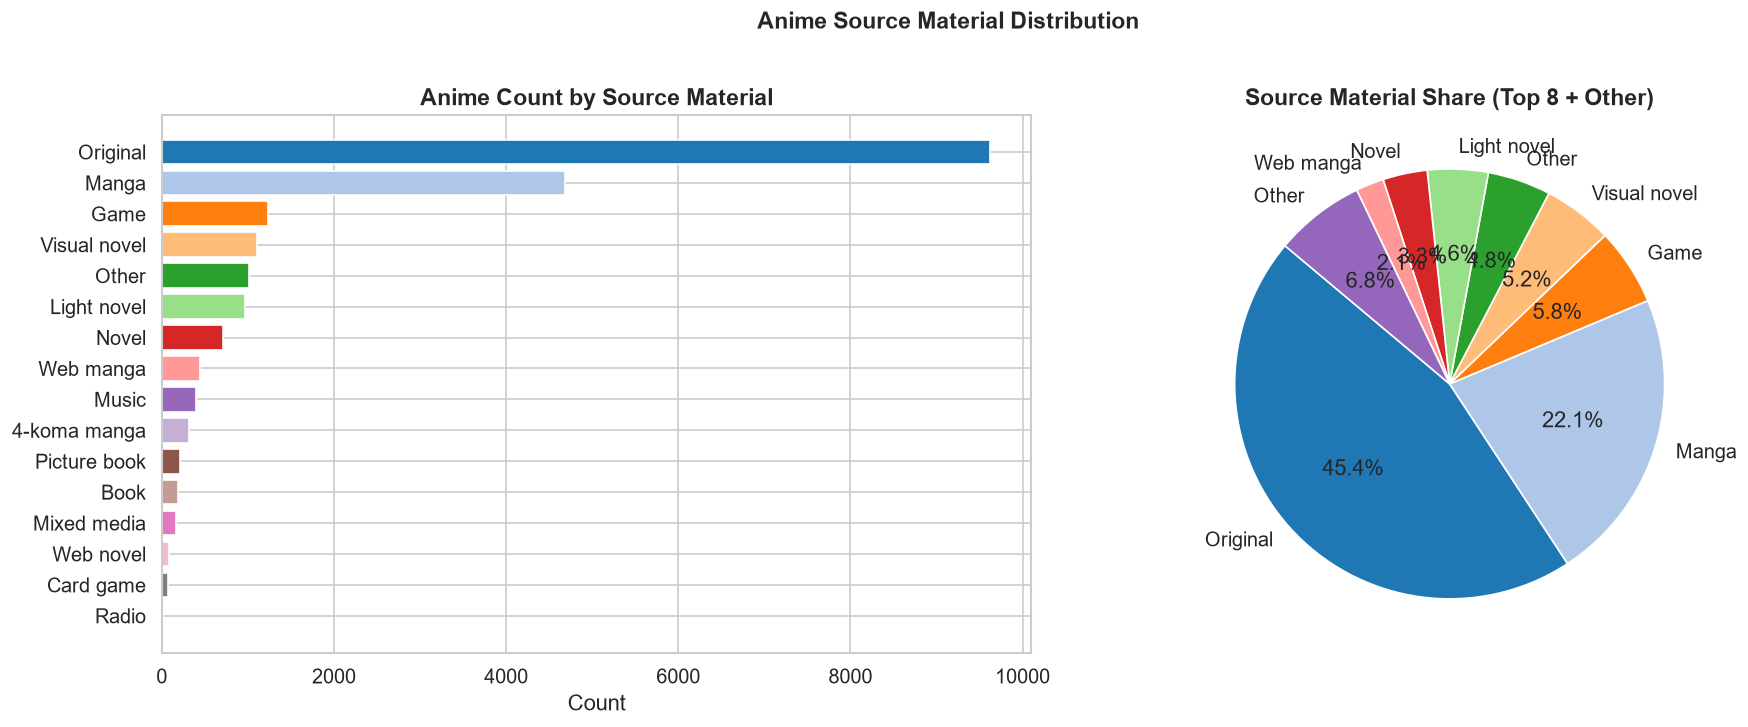

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette_s = sns.color_palette('tab20', len(source_counts))

# Bar chart
axes[0].barh(source_counts['Source'][::-1], source_counts['Count'][::-1], color=palette_s[::-1])
axes[0].set_xlabel('Count')
axes[0].set_title('Anime Count by Source Material')

# Pie (top 8 + Other)
top8 = source_counts.head(8)
other_count = source_counts.iloc[8:]['Count'].sum()
pie_data = pd.concat([
    top8,
    pd.DataFrame([{'Source': 'Other', 'Count': other_count}])
], ignore_index=True)
axes[1].pie(pie_data['Count'], labels=pie_data['Source'],
            autopct='%1.1f%%', colors=sns.color_palette('tab20', len(pie_data)), startangle=140)
axes[1].set_title('Source Material Share (Top 8 + Other)')

plt.suptitle('Anime Source Material Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('source_distribution.png', bbox_inches='tight')
plt.show()

In [38]:
# ── 9.2  Average score by source (min 20 scored titles) ──────────────────────
source_score = (
    df[df['Score'].notna() & df['Source'].notna()]
    .groupby('Source')
    .agg(Avg_Score=('Score', 'mean'), Count=('Score', 'count'))
    .reset_index()
)
source_score = source_score[source_score['Count'] >= 20].sort_values('Avg_Score', ascending=False)
print('Source materials by average score (≥20 titles):')
source_score

Source materials by average score (≥20 titles):


,Source,Avg_Score,Count
15,Web novel,6.996429,42
4,Light novel,6.959065,877
5,Manga,6.830063,4150
14,Web manga,6.749270,315
8,Novel,6.715667,540
0,4-koma manga,6.656107,280
1,Book,6.452418,91
6,Mixed media,6.440804,112
2,Card game,6.318154,65
3,Game,6.305921,956


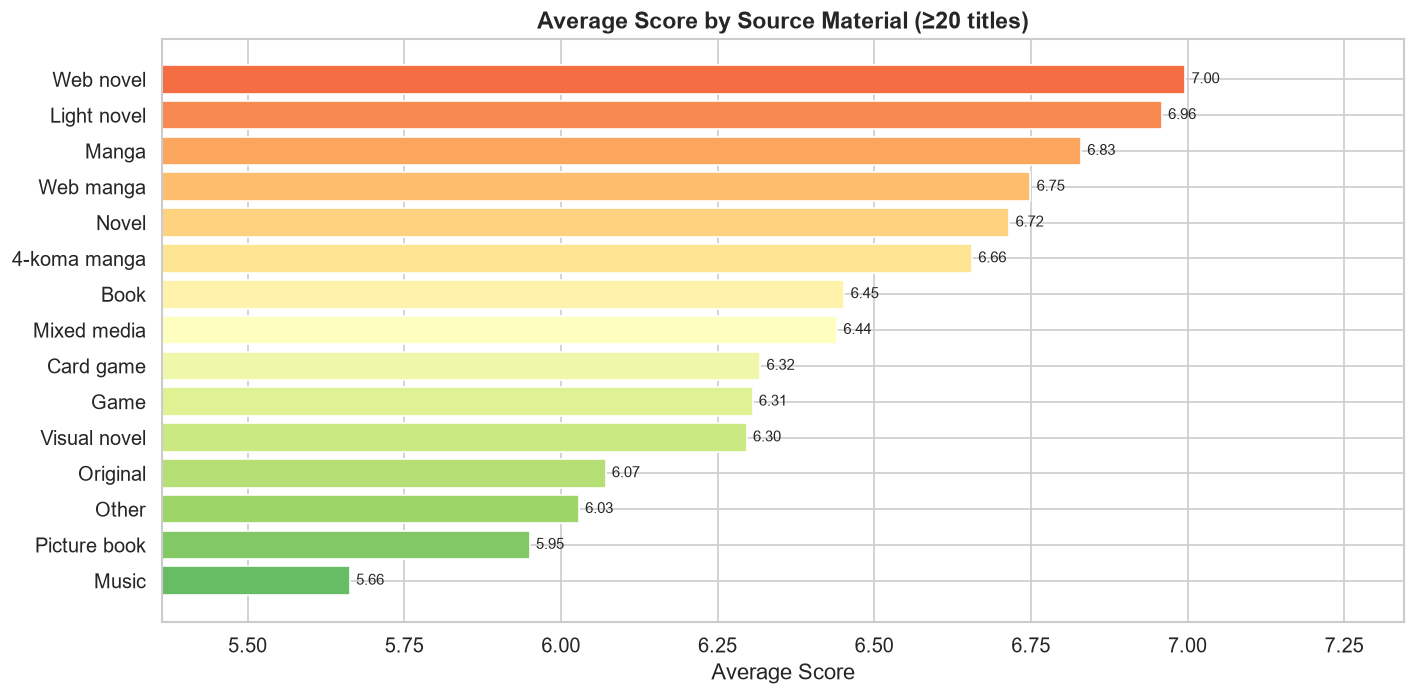

In [39]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(source_score)))
bars = ax.barh(source_score['Source'][::-1], source_score['Avg_Score'][::-1], color=colors[::-1])
ax.set_xlabel('Average Score')
ax.set_title('Average Score by Source Material (≥20 titles)')
ax.set_xlim(left=source_score['Avg_Score'].min() - 0.3)
for bar, val in zip(bars, source_score['Avg_Score'][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('source_avg_score.png', bbox_inches='tight')
plt.show()

---
## 10. Release Trend Analysis

In [40]:
# ── 10.1  Anime count per year ────────────────────────────────────────────────
year_df = df[df['Release_Year'].notna() & (df['Release_Year'] >= 1960) & (df['Release_Year'] <= 2023)].copy()
year_df['Release_Year'] = year_df['Release_Year'].astype(int)

anime_per_year = year_df.groupby('Release_Year').size().reset_index(name='Count')
print(f'Years covered: {anime_per_year["Release_Year"].min()} – {anime_per_year["Release_Year"].max()}')
anime_per_year.tail(10)

Years covered: 1960 – 2023


,Release_Year,Count
54,2014,1050
55,2015,1047
56,2016,1175
57,2017,1221
58,2018,1165
59,2019,1130
60,2020,1077
61,2021,1105
62,2022,1040
63,2023,608


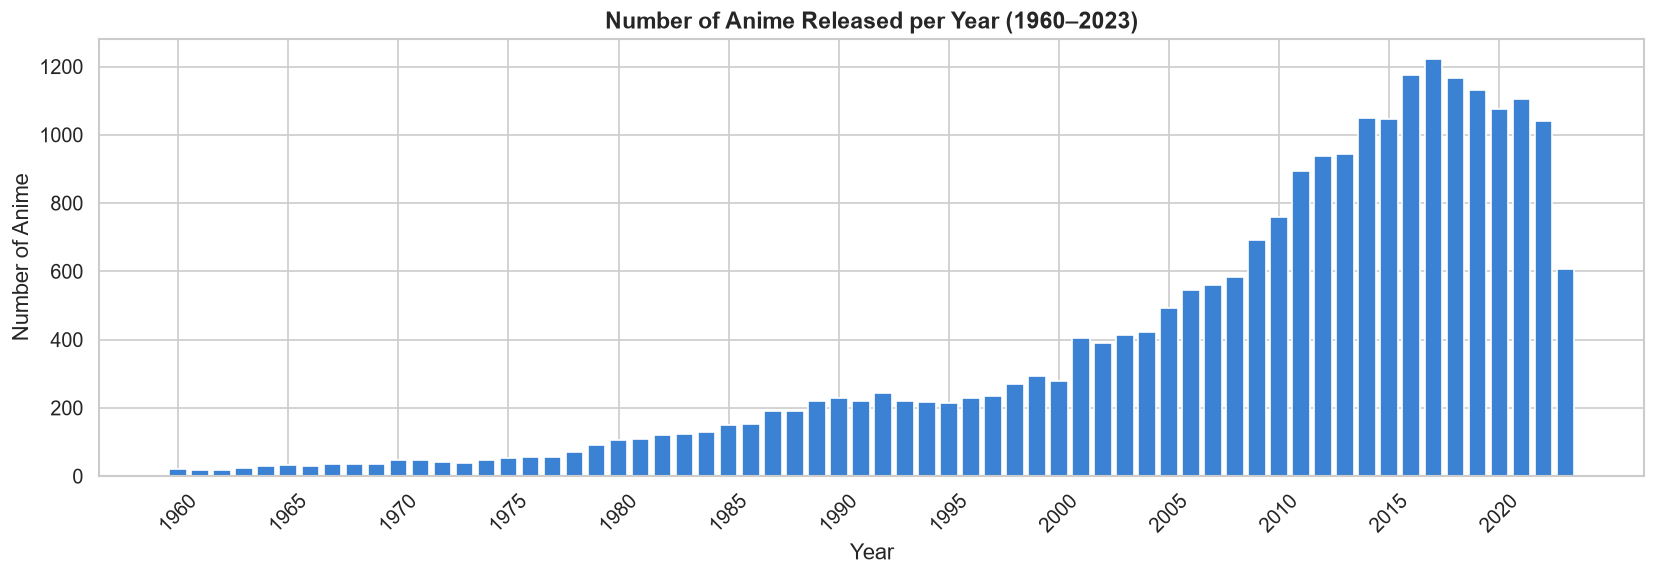

In [41]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(anime_per_year['Release_Year'], anime_per_year['Count'], color=ACCENT, width=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Anime')
ax.set_title('Number of Anime Released per Year (1960–2023)')
ax.set_xticks(range(1960, 2024, 5))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('anime_per_year.png', bbox_inches='tight')
plt.show()

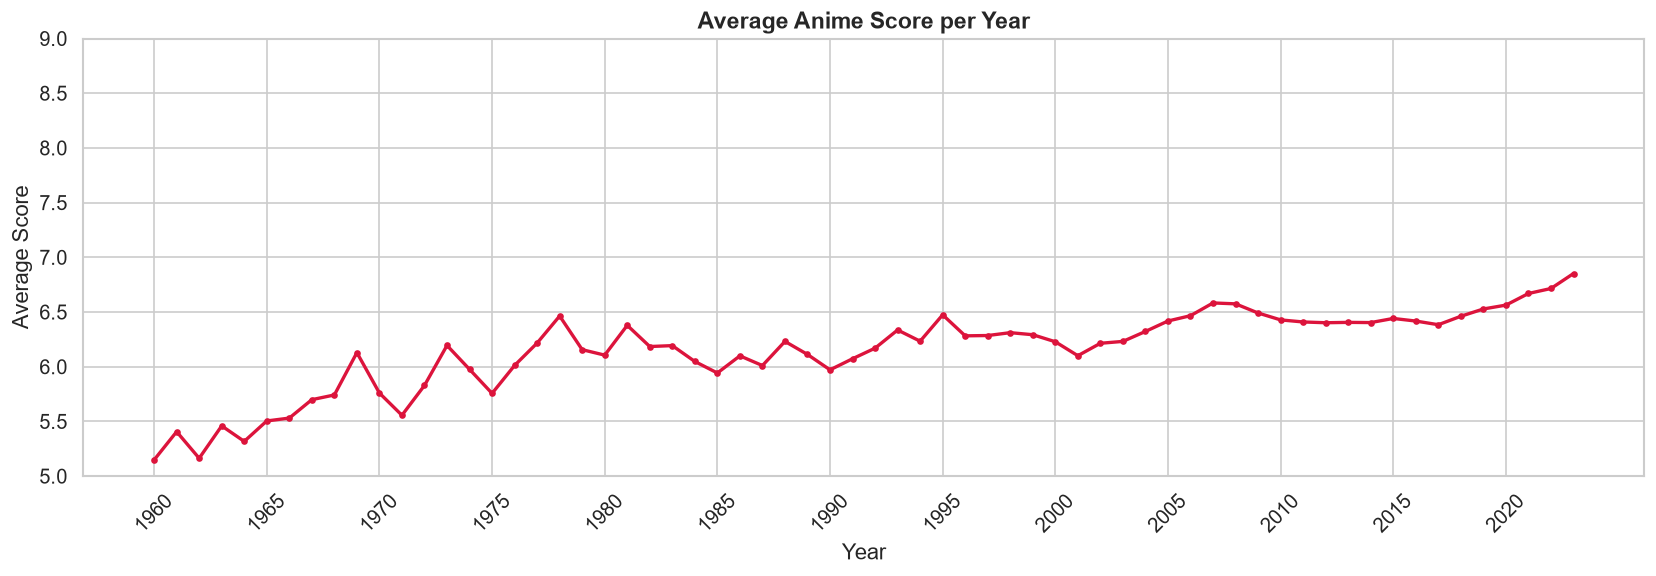

In [42]:
# ── 10.2  Average score per year ──────────────────────────────────────────────
score_per_year = (
    year_df[year_df['Score'].notna()]
    .groupby('Release_Year')['Score']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'Avg_Score', 'count': 'N'})
)
# Only plot years with ≥5 scored titles
score_per_year = score_per_year[score_per_year['N'] >= 5]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(score_per_year['Release_Year'], score_per_year['Avg_Score'], color='crimson', linewidth=2, marker='o', markersize=3)
ax.set_xlabel('Year')
ax.set_ylabel('Average Score')
ax.set_title('Average Anime Score per Year')
ax.set_xticks(range(int(score_per_year['Release_Year'].min()), 2024, 5))
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(5, 9)
plt.tight_layout()
plt.savefig('avg_score_per_year.png', bbox_inches='tight')
plt.show()

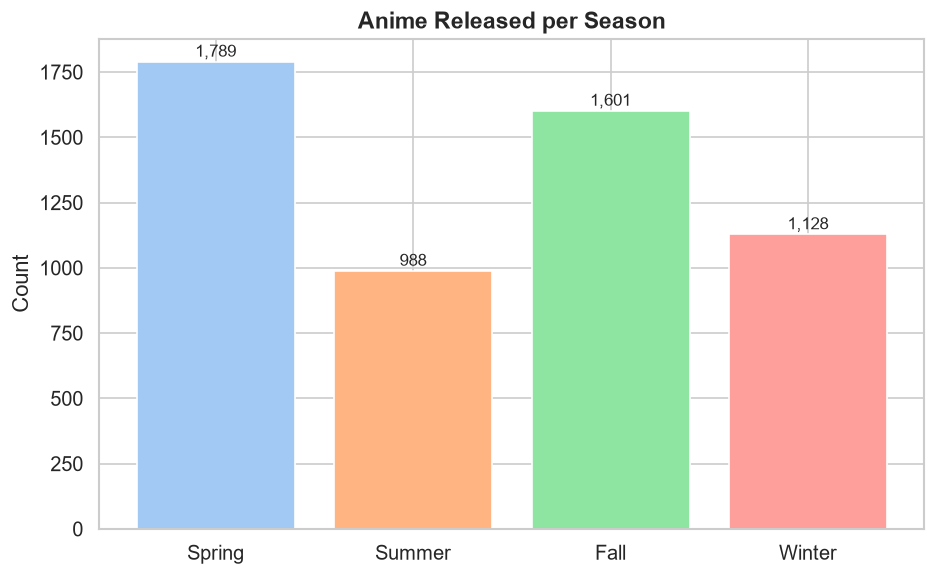

In [43]:
# ── 10.3  Count by season ─────────────────────────────────────────────────────
season_counts = df['Premiere_Season'].value_counts().reset_index()
season_counts.columns = ['Season', 'Count']

season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_counts = season_counts.set_index('Season').reindex(season_order).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
palette_season = sns.color_palette('pastel', 4)
bars = ax.bar(season_counts['Season'], season_counts['Count'], color=palette_season)
ax.set_ylabel('Count')
ax.set_title('Anime Released per Season')
for bar, val in zip(bars, season_counts['Count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{int(val):,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('anime_by_season.png', bbox_inches='tight')
plt.show()

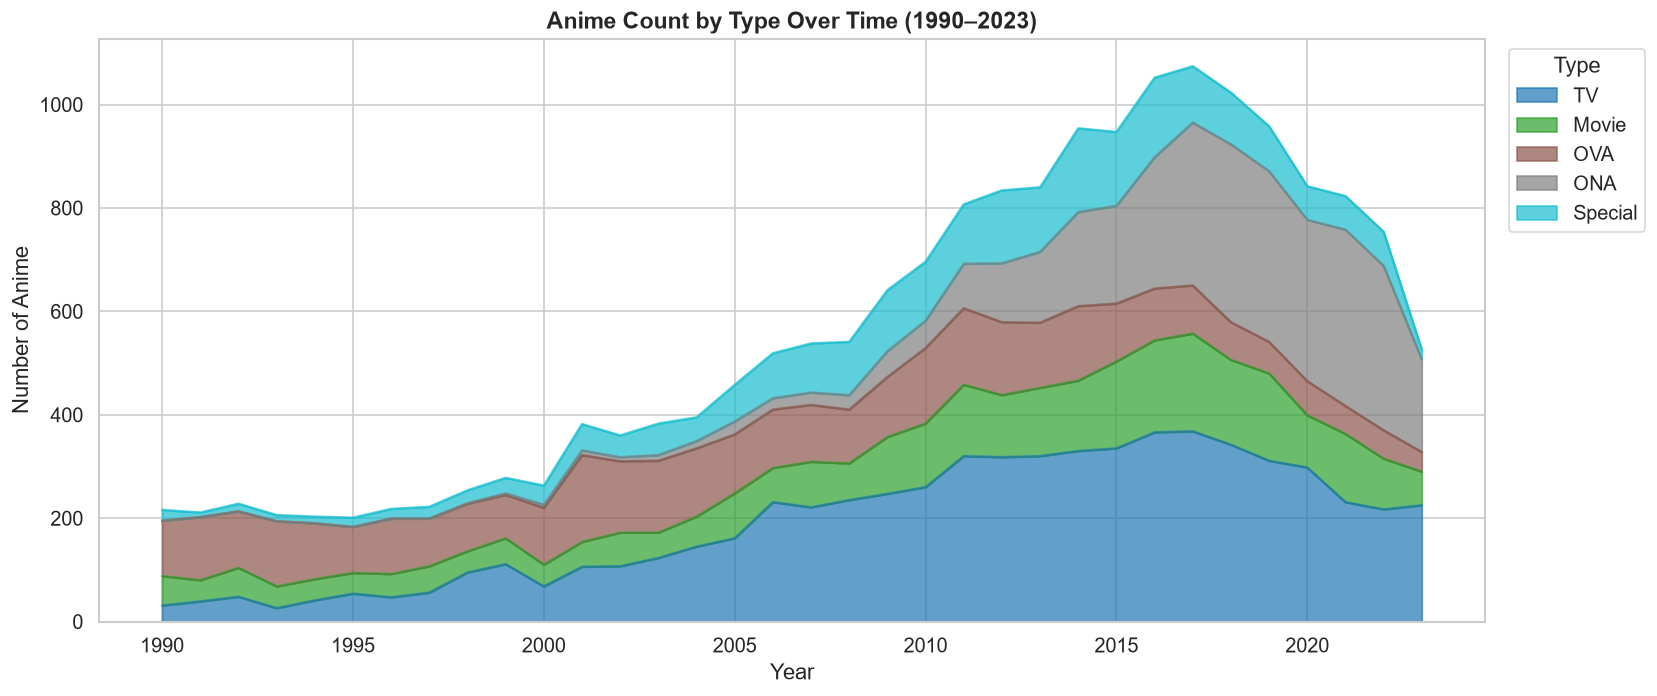

In [44]:
# ── 10.4  Anime count by Type over time (1990–2023) ───────────────────────────
type_year = (
    year_df[year_df['Type'].notna() & (year_df['Release_Year'] >= 1990)]
    .groupby(['Release_Year', 'Type'])
    .size()
    .unstack(fill_value=0)
)

main_types = ['TV', 'Movie', 'OVA', 'ONA', 'Special']
type_year_filtered = type_year[[c for c in main_types if c in type_year.columns]]

fig, ax = plt.subplots(figsize=(14, 6))
type_year_filtered.plot(kind='area', ax=ax, alpha=0.7, colormap='tab10')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Anime')
ax.set_title('Anime Count by Type Over Time (1990–2023)')
ax.legend(title='Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('type_over_time.png', bbox_inches='tight')
plt.show()

---
## 11. Correlation Analysis

In [45]:
# ── 11.1  Correlation matrix of numerical features ────────────────────────────
num_cols = ['Score', 'Rank', 'Popularity', 'Favorites', 'Scored By', 'Members', 'Episodes', 'Duration_min']
corr_df = df[num_cols].copy()

# Invert Rank so higher rank = better for intuitive correlation
corr_df['Rank_inv'] = corr_df['Rank'].max() - corr_df['Rank']
corr_df = corr_df.drop(columns=['Rank'])

corr_matrix = corr_df.corr()
print('Correlation matrix:')
corr_matrix.round(3)

Correlation matrix:


,Score,Popularity,Favorites,Scored By,Members,Episodes,Duration_min,Rank_inv
Score,1.000,-0.698,0.235,0.351,0.391,0.079,0.298,0.977
Popularity,-0.698,1.000,-0.163,-0.377,-0.364,0.091,-0.227,-0.872
Favorites,0.235,-0.163,1.000,0.785,0.773,0.045,0.026,0.169
Scored By,0.351,-0.377,0.785,1.000,0.989,0.054,0.065,0.335
Members,0.391,-0.364,0.773,0.989,1.000,0.027,0.072,0.340
Episodes,0.079,0.091,0.045,0.054,0.027,1.000,-0.086,-0.064
Duration_min,0.298,-0.227,0.026,0.065,0.072,-0.086,1.000,0.206
Rank_inv,0.977,-0.872,0.169,0.335,0.340,-0.064,0.206,1.000


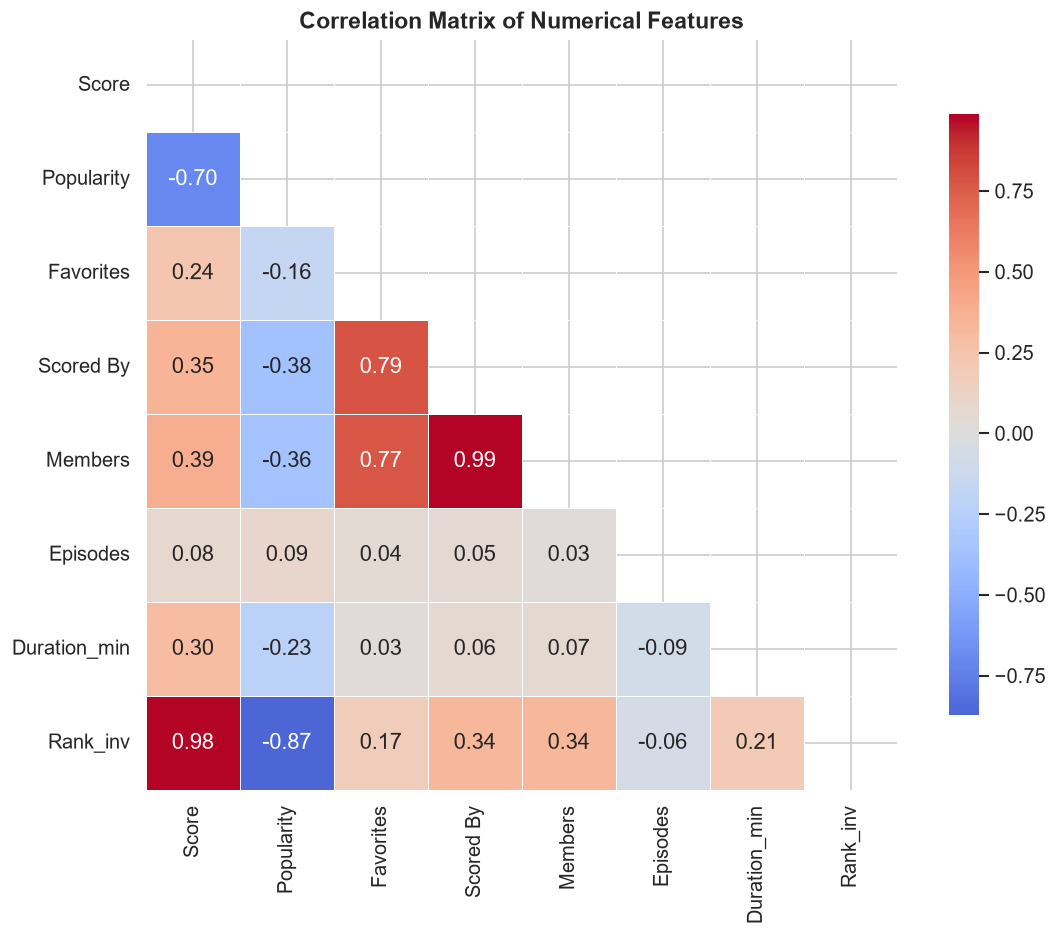

In [46]:
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, square=True, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()

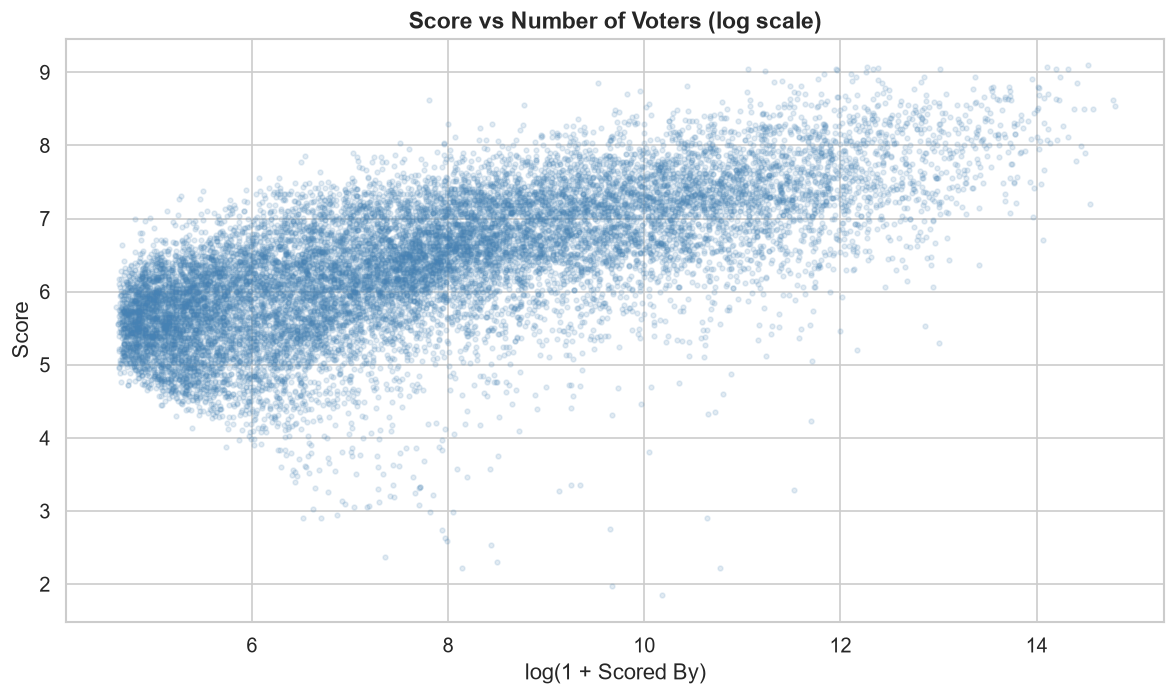

In [47]:
# ── 11.2  Score vs Scored By ──────────────────────────────────────────────────
plot2 = df[df['Score'].notna() & df['Scored By'].notna() & (df['Scored By'] > 0)].copy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(np.log1p(plot2['Scored By']), plot2['Score'],
           alpha=0.15, s=8, c='steelblue')
ax.set_xlabel('log(1 + Scored By)')
ax.set_ylabel('Score')
ax.set_title('Score vs Number of Voters (log scale)')
plt.tight_layout()
plt.savefig('score_vs_voters.png', bbox_inches='tight')
plt.show()

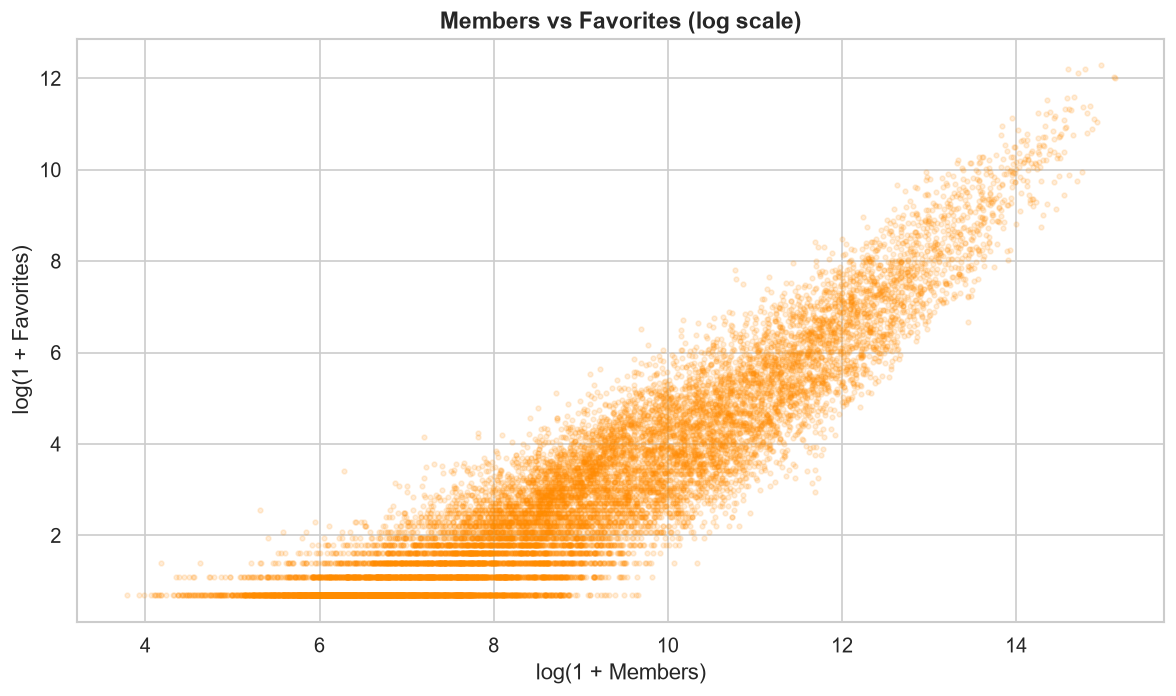

In [48]:
# ── 11.3  Members vs Favorites ────────────────────────────────────────────────
plot3 = df[(df['Members'] > 0) & (df['Favorites'] > 0)].copy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(np.log1p(plot3['Members']), np.log1p(plot3['Favorites']),
           alpha=0.15, s=8, c='darkorange')
ax.set_xlabel('log(1 + Members)')
ax.set_ylabel('log(1 + Favorites)')
ax.set_title('Members vs Favorites (log scale)')
plt.tight_layout()
plt.savefig('members_vs_favorites.png', bbox_inches='tight')
plt.show()

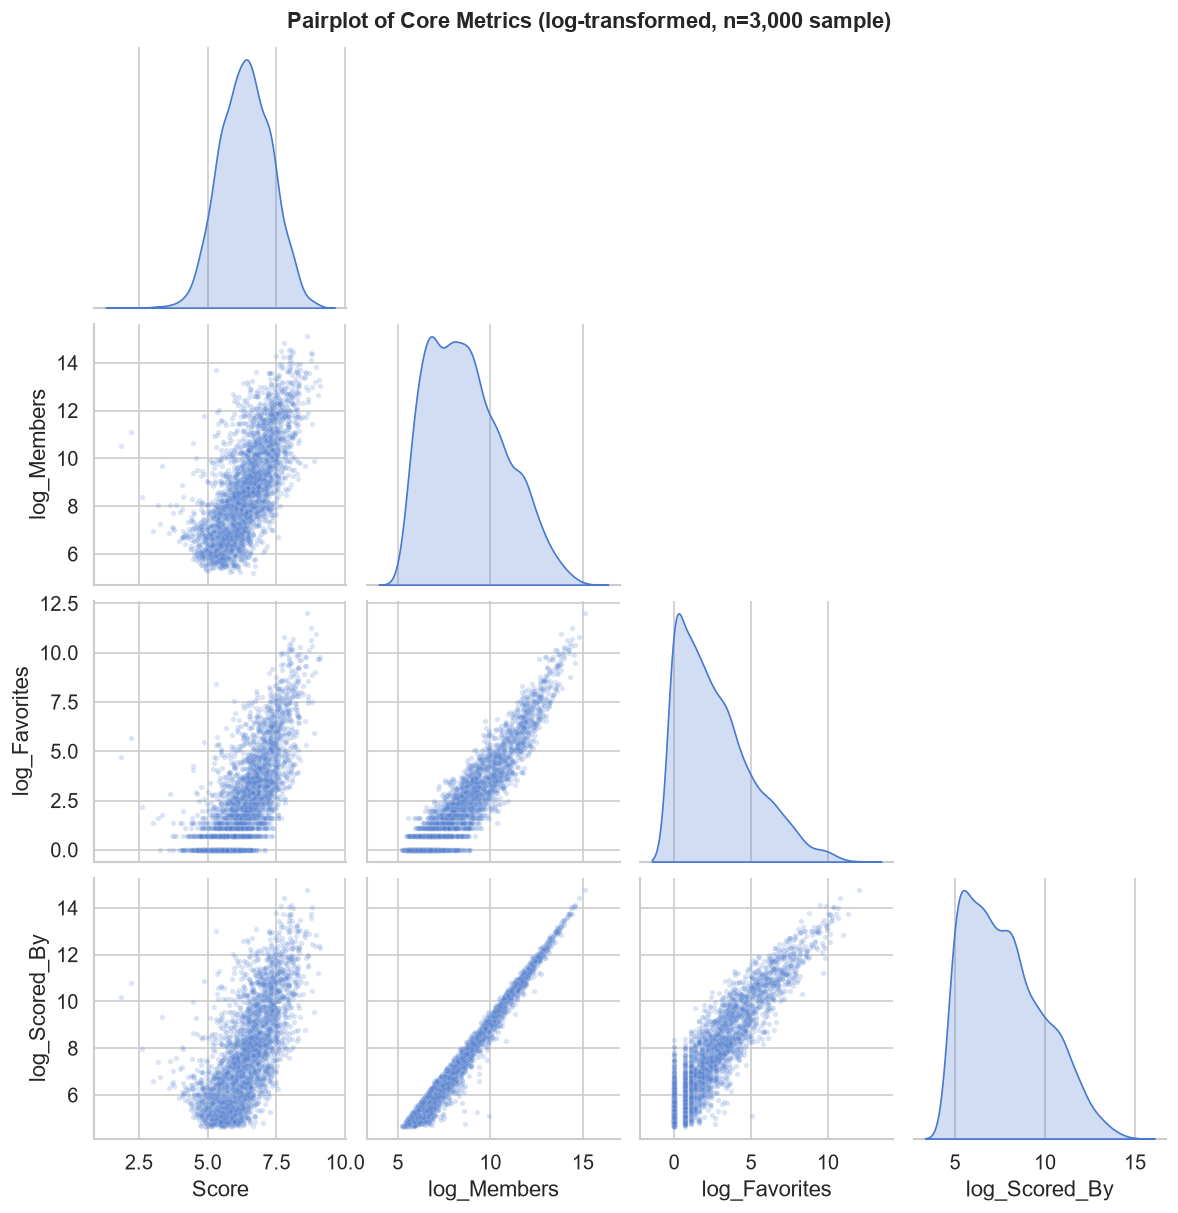

In [49]:
# ── 11.4  Pairplot of core metrics (sample for performance) ──────────────────
pair_cols = ['Score', 'Members', 'Favorites', 'Scored By']
pair_df = df[pair_cols].dropna().sample(n=min(3000, df[pair_cols].dropna().shape[0]), random_state=42)
# Log-transform skewed columns
for c in ['Members', 'Favorites', 'Scored By']:
    pair_df[c] = np.log1p(pair_df[c])
pair_df.columns = ['Score', 'log_Members', 'log_Favorites', 'log_Scored_By']

g = sns.pairplot(pair_df, diag_kind='kde', plot_kws={'alpha': 0.2, 's': 10}, corner=True)
g.fig.suptitle('Pairplot of Core Metrics (log-transformed, n=3,000 sample)', y=1.01, fontsize=13, fontweight='bold')
plt.savefig('pairplot.png', bbox_inches='tight')
plt.show()

---
## 12. Key Findings

In [50]:
# ── Compute summary statistics for the findings narrative ─────────────────────
scored_series = df['Score'].dropna()
best_anime = df[df['Scored By'] >= 1000].nlargest(1, 'Score')[['Name', 'Score']].iloc[0]
top_genre = genre_counts.iloc[0]
top_studio_count = studio_counts.iloc[0]
top_source = source_counts.iloc[0]
peak_year_row = anime_per_year.loc[anime_per_year['Count'].idxmax()]
top_member_anime = df.nlargest(1, 'Members')[['Name', 'Members']].iloc[0]

print('=== KEY FINDINGS ===')
print(f"Dataset size      : {len(df):,} anime titles")
print(f"Score range       : {scored_series.min():.2f} – {scored_series.max():.2f}")
print(f"Mean score        : {scored_series.mean():.2f}  |  Median: {scored_series.median():.2f}")
print(f"Highest rated     : {best_anime['Name']} ({best_anime['Score']:.2f})")
print(f"Most popular (Members): {top_member_anime['Name']} ({top_member_anime['Members']:,})")
print(f"Top genre         : {top_genre['Genre']} ({top_genre['Count']:,} titles)")
print(f"Most prolific studio: {top_studio_count['Studio']} ({top_studio_count['Count']} titles)")
print(f"Top source material : {top_source['Source']} ({top_source['Count']:,} titles)")
print(f"Peak release year : {int(peak_year_row['Release_Year'])} ({peak_year_row['Count']:,} titles)")
print(f"Missing scores    : {df['Score'].isna().sum():,} ({df['Score'].isna().mean()*100:.1f}%)")

=== KEY FINDINGS ===
Dataset size      : 24,905 anime titles
Score range       : 1.85 – 9.10
Mean score        : 6.38  |  Median: 6.39
Highest rated     : Fullmetal Alchemist: Brotherhood (9.10)
Most popular (Members): Shingeki no Kyojin (3,744,541)
Top genre         : Comedy (7,142 titles)
Most prolific studio: Toei Animation (864 titles)
Top source material : Original (9,622 titles)
Peak release year : 2017 (1,221 titles)
Missing scores    : 9,213 (37.0%)


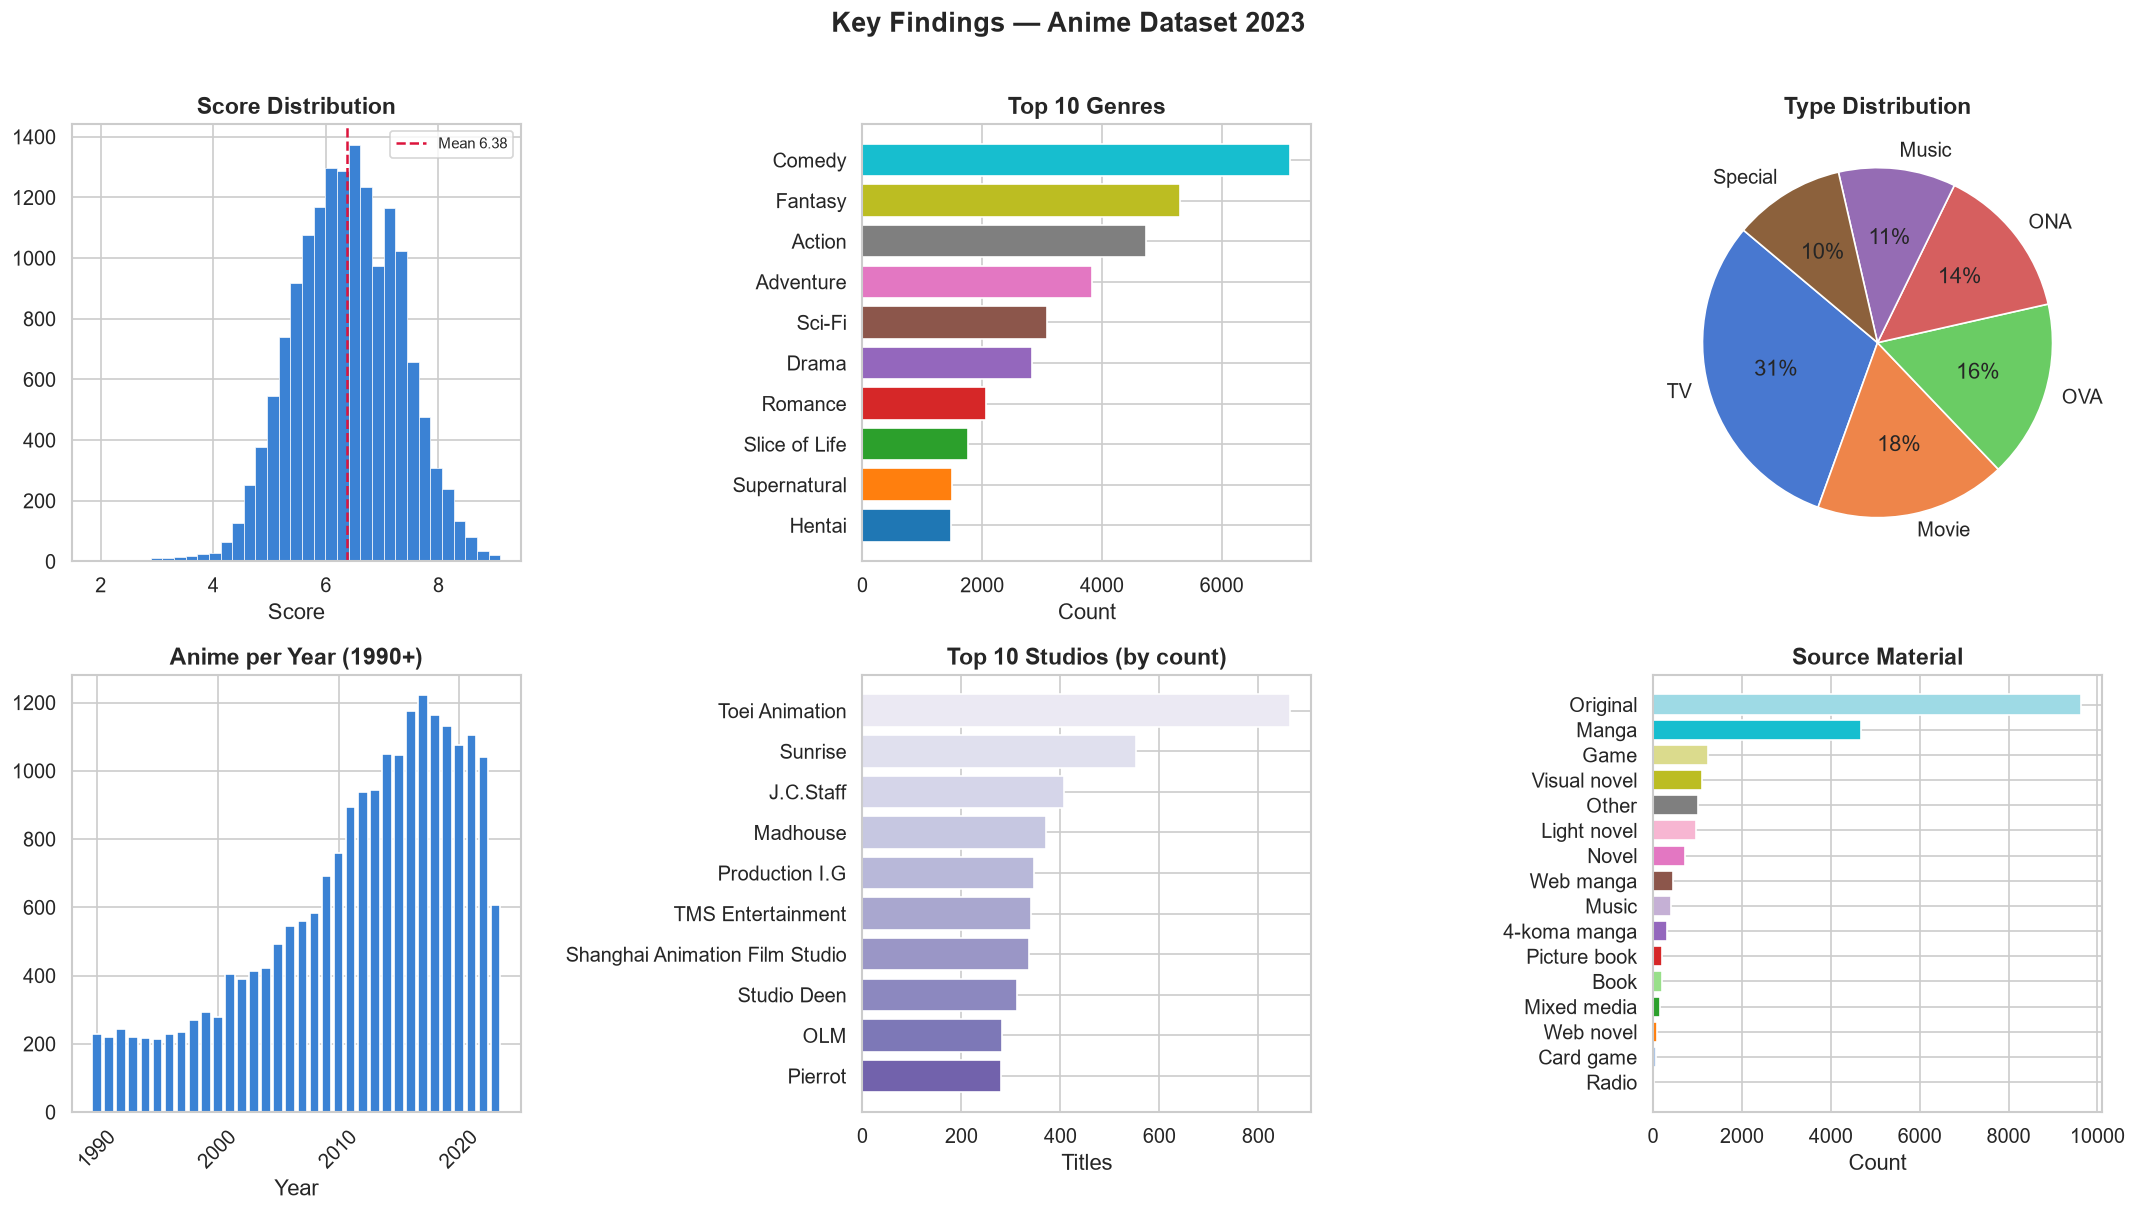

In [51]:
# ── Key Findings Summary Plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Key Findings — Anime Dataset 2023', fontsize=16, fontweight='bold', y=1.01)

# Plot 1: Score histogram
axes[0,0].hist(scored_series, bins=35, color=ACCENT, edgecolor='white', linewidth=0.4)
axes[0,0].axvline(scored_series.mean(), color='crimson', linestyle='--', linewidth=1.5, label=f'Mean {scored_series.mean():.2f}')
axes[0,0].set_title('Score Distribution')
axes[0,0].set_xlabel('Score')
axes[0,0].legend(fontsize=9)

# Plot 2: Top 10 genres
gc10 = genre_counts.head(10)
axes[0,1].barh(gc10['Genre'][::-1], gc10['Count'][::-1], color=plt.cm.tab10(np.linspace(0,1,10)))
axes[0,1].set_title('Top 10 Genres')
axes[0,1].set_xlabel('Count')

# Plot 3: Type distribution pie
tc_nona = type_counts[type_counts['Type'].notna()]
axes[0,2].pie(tc_nona['Count'], labels=tc_nona['Type'],
              autopct='%1.0f%%', colors=sns.color_palette('muted', len(tc_nona)), startangle=140)
axes[0,2].set_title('Type Distribution')

# Plot 4: Anime per year
recent = anime_per_year[anime_per_year['Release_Year'] >= 1990]
axes[1,0].bar(recent['Release_Year'], recent['Count'], color=ACCENT, width=0.8)
axes[1,0].set_title('Anime per Year (1990+)')
axes[1,0].set_xlabel('Year')
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 5: Top 10 studios by count
sc10 = studio_counts.head(10)
axes[1,1].barh(sc10['Studio'][::-1], sc10['Count'][::-1], color=plt.cm.Purples_r(np.linspace(0.3, 0.85, 10)))
axes[1,1].set_title('Top 10 Studios (by count)')
axes[1,1].set_xlabel('Titles')

# Plot 6: Source pie
axes[1,2].barh(source_counts['Source'][::-1], source_counts['Count'][::-1],
               color=plt.cm.tab20(np.linspace(0, 1, len(source_counts))))
axes[1,2].set_title('Source Material')
axes[1,2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('key_findings_summary.png', bbox_inches='tight')
plt.show()

---
## 13. Conclusion

### Summary of Findings

This exploratory data analysis of 24,905 anime titles from the 2023 MyAnimeList dataset reveals the following key insights:

#### Dataset Quality
- The dataset contains **no true NaN values** — missing data is represented by the sentinel string `'UNKNOWN'`, which required explicit handling during cleaning.
- Several columns (`Score`, `Rank`, `Scored By`, `Episodes`) were stored as strings and converted to numeric types.
- ~34% of titles have no score (either too new or not rated).

#### Scores
- Scores follow a roughly **left-skewed normal distribution** centred around 6.5–7.0.
- The highest-rated titles (≥1,000 voters) cluster between 8.5 and 9.5.
- **Movies and TV series** tend to score higher than OVAs, ONAs, and Music.

#### Popularity & Engagement
- `Members`, `Favorites`, and `Scored By` are all **heavily right-skewed** — a small number of titles capture the vast majority of engagement.
- Higher member counts correlate positively with higher scores, but many highly-watched titles have mediocre scores.

#### Genres
- **Action, Comedy, and Fantasy** are the most common genres.
- Award Winning and Josei genres achieve the highest average scores, though with fewer titles.

#### Studios
- **Toei Animation** produces the most titles; studios like **Madhouse** and **Bones** lead on average score.
- Studio output is highly concentrated — the top 20 studios account for a disproportionate share of all titles.

#### Source Material
- **Original** works dominate by count, but **Light Novels** and **Visual Novels** tend to achieve higher average scores.
- Manga-adapted anime represent the second-largest source category.

#### Release Trends
- Anime production has **grown dramatically since the 1990s**, with recent years (2015–2022) showing peak output.
- **Fall and Spring** are the busiest seasons for new releases.
- The rise of **ONA (original net animation)** is a defining trend of the 2010s–2020s.

#### Correlations
- `Score` and `Scored By` have a moderate positive correlation — more-watched anime tend to be better rated.
- `Members` and `Favorites` are strongly correlated, confirming that audience size drives favourites.
- `Episodes` and `Duration` show weak or no meaningful correlation with score.

---
*End of Exploratory Data Analysis*